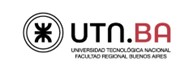

###**Trabajo Semanal 3**
**Teoria de los Circuitos 2**


Autor: Alan Nicolas Parizek


Profesor: Mariano Llamedo Soria  
Ayudante de TPs: David Moharos  
Jefe de TPs: César Fuoco  




###Consignas


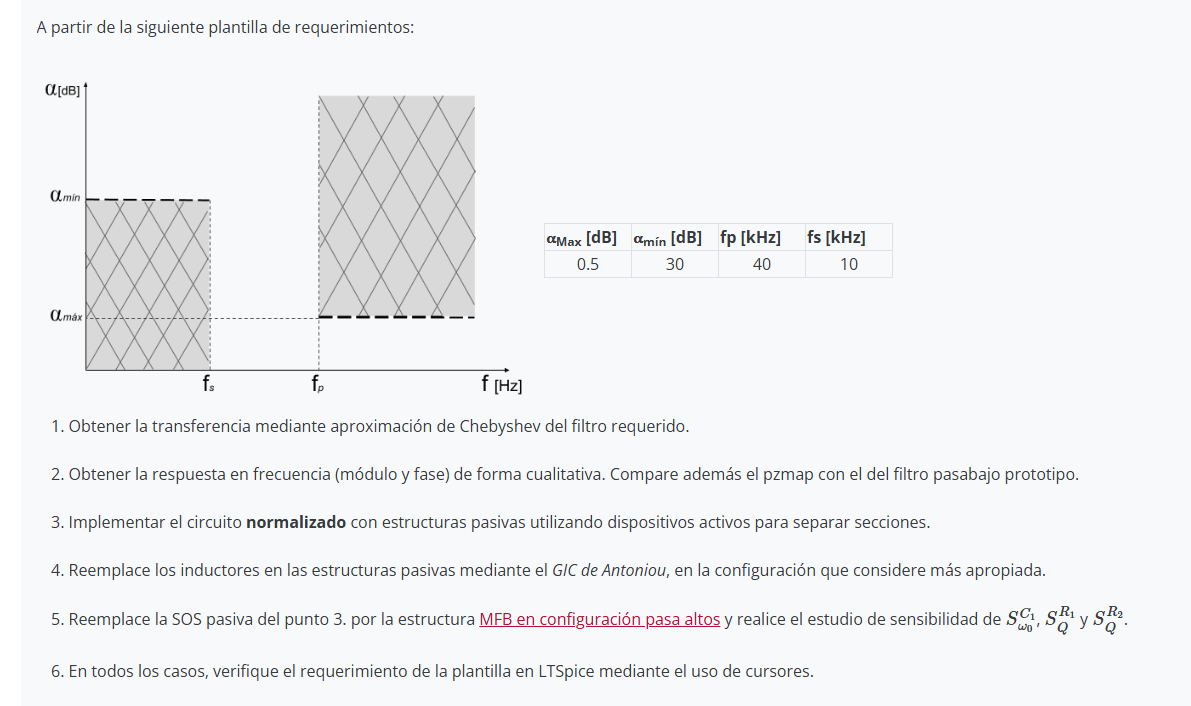

###Imports

In [3]:
import sympy as sp
import numpy as np
from pytc2.remociones import remover_polo_dc
from pytc2.general import a_equal_b_latex_s, print_latex, s, symbfunc2tf, factorSOS
from pytc2.sistemas_lineales import bodePlot, pretty_print_SOS, tf2sos_analog
import scipy.signal as sig

In [4]:
import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt
from pytc2.sistemas_lineales import analyze_sys, bodePlot, pzmap, pretty_print_bicuad_omegayq
from pytc2.general import print_latex, a_equal_b_latex_s

# módulo de SciPy
from scipy import signal as sig

# Esta parte de código la agregamos SOLO en los notebooks para fijar el estilo de los gráficos.
fig_sz_x = 13
fig_sz_y = 7
fig_dpi = 80 # dpi
fig_font_size = 13

mpl.rcParams['figure.figsize'] = (fig_sz_x, fig_sz_y)
mpl.rcParams['figure.dpi'] = fig_dpi
plt.rcParams.update({'font.size':fig_font_size})

###Desarrollo

Primero, obtengo la transferencia objetivo planteando un prototipo pasa-bajos.

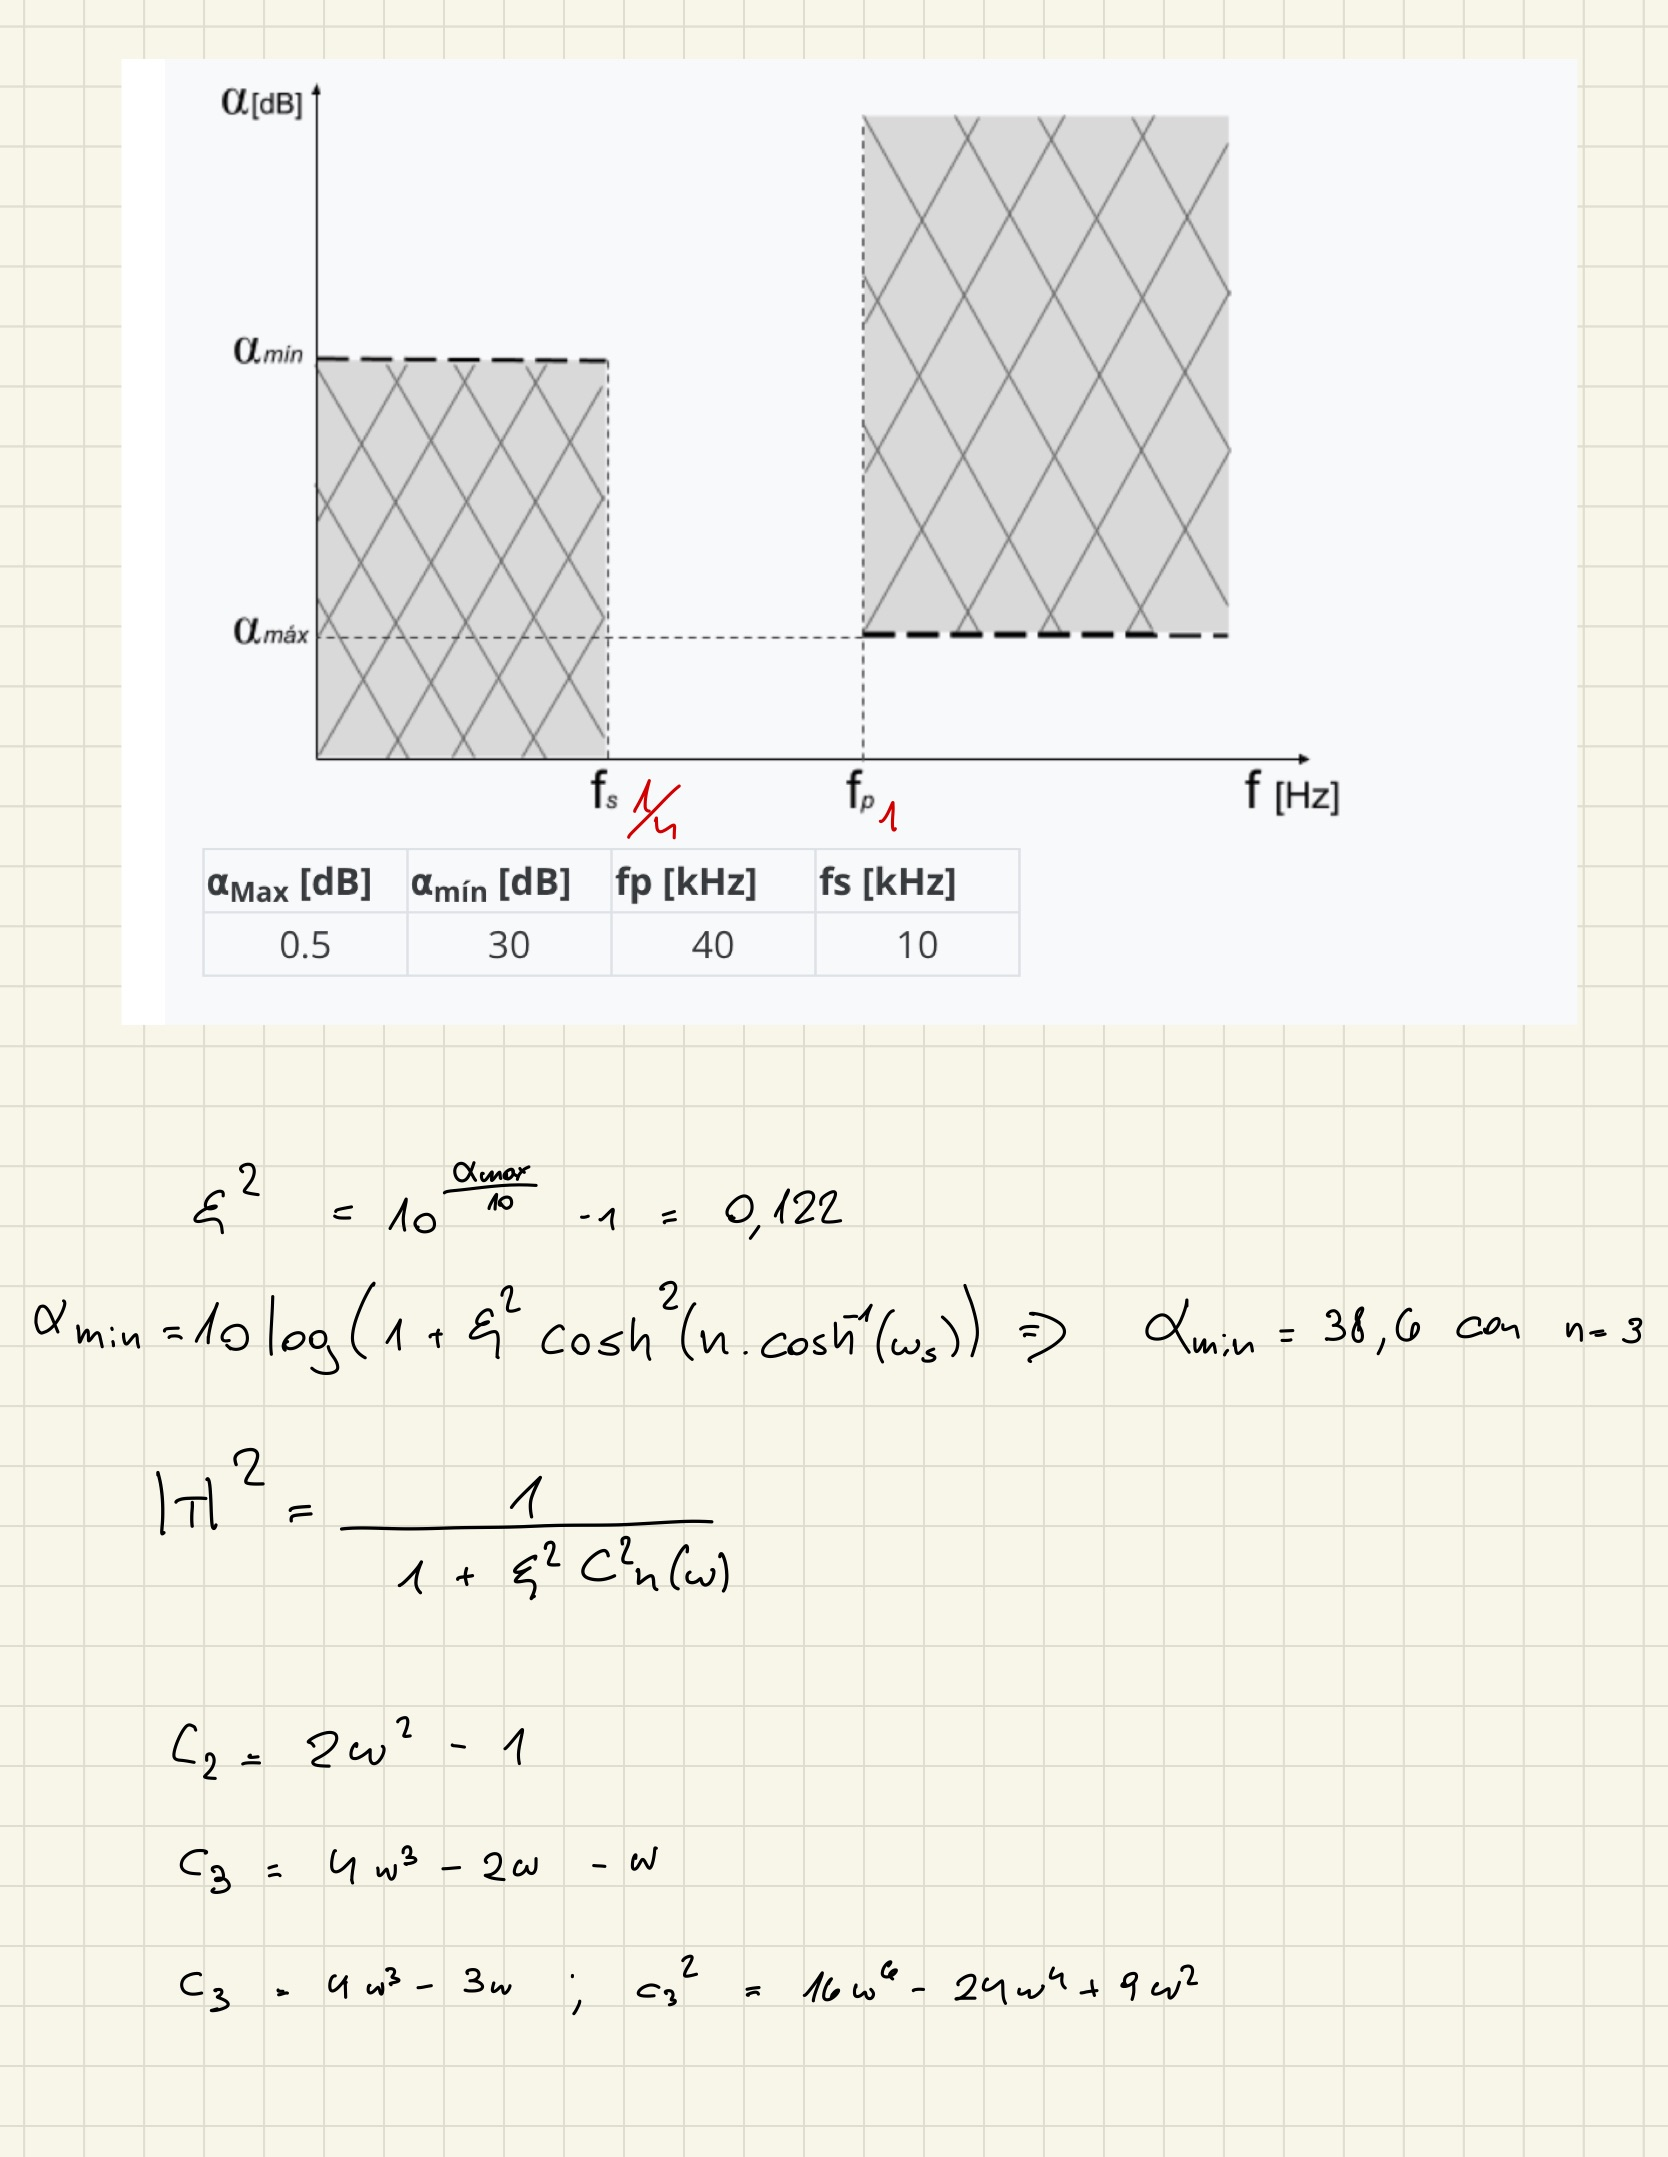

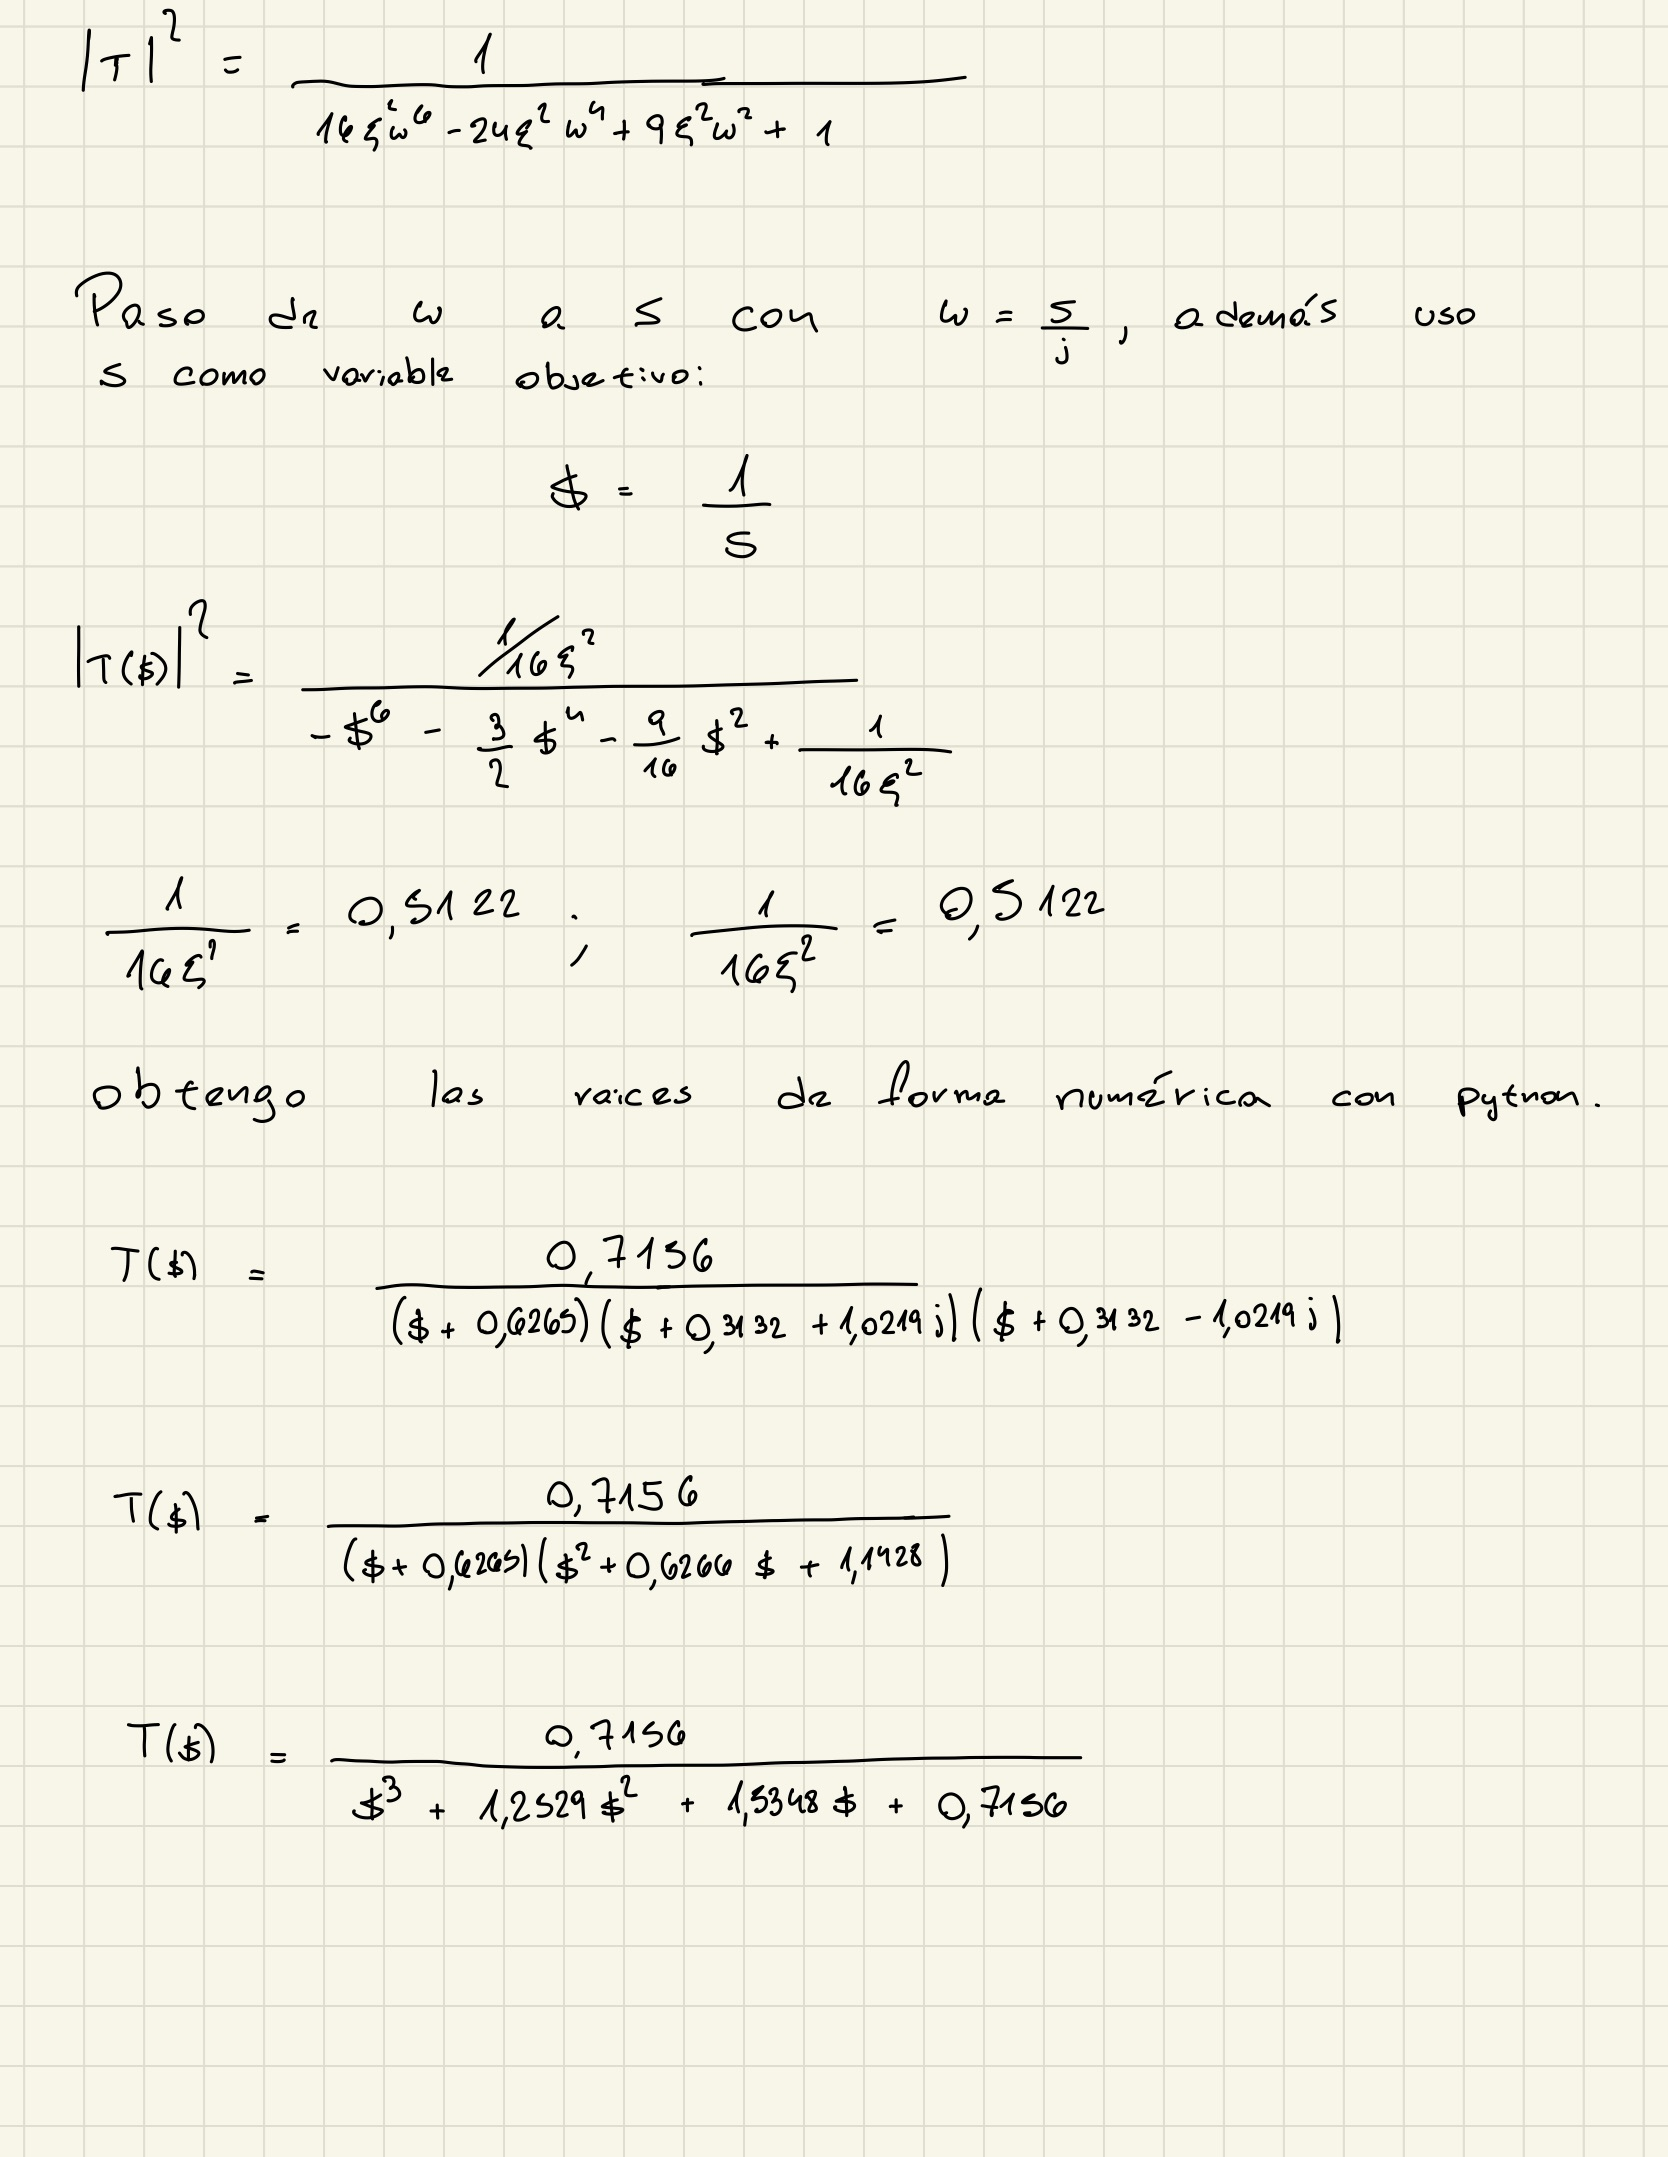

Con el codigo que sigue se puede ver como se buscan las raices del polinomio grado 6 obtenido analiticamente y luego se guardan las raices del semiplano izquierdo. Ademas, se buscan los coeficientes de la transferencia para comparar resultados.

In [7]:
#calculo las raices de mi t(s)
raices = np.roots([-1,0,-3/2,0,-9/16,0,0.5122])

raices_spi = raices[np.real(raices) < 0]



print("Raices del Denominador: ", raices_spi)
den_from_poles = np.poly(raices_spi)

print("coeficientes de la transferencia: ", den_from_poles)


Raices del Denominador:  [-0.31322505+1.02192456j -0.31322505-1.02192456j -0.62645011+0.j        ]
coeficientes de la transferencia:  [1.         1.25290021 1.53487947 0.71568149]


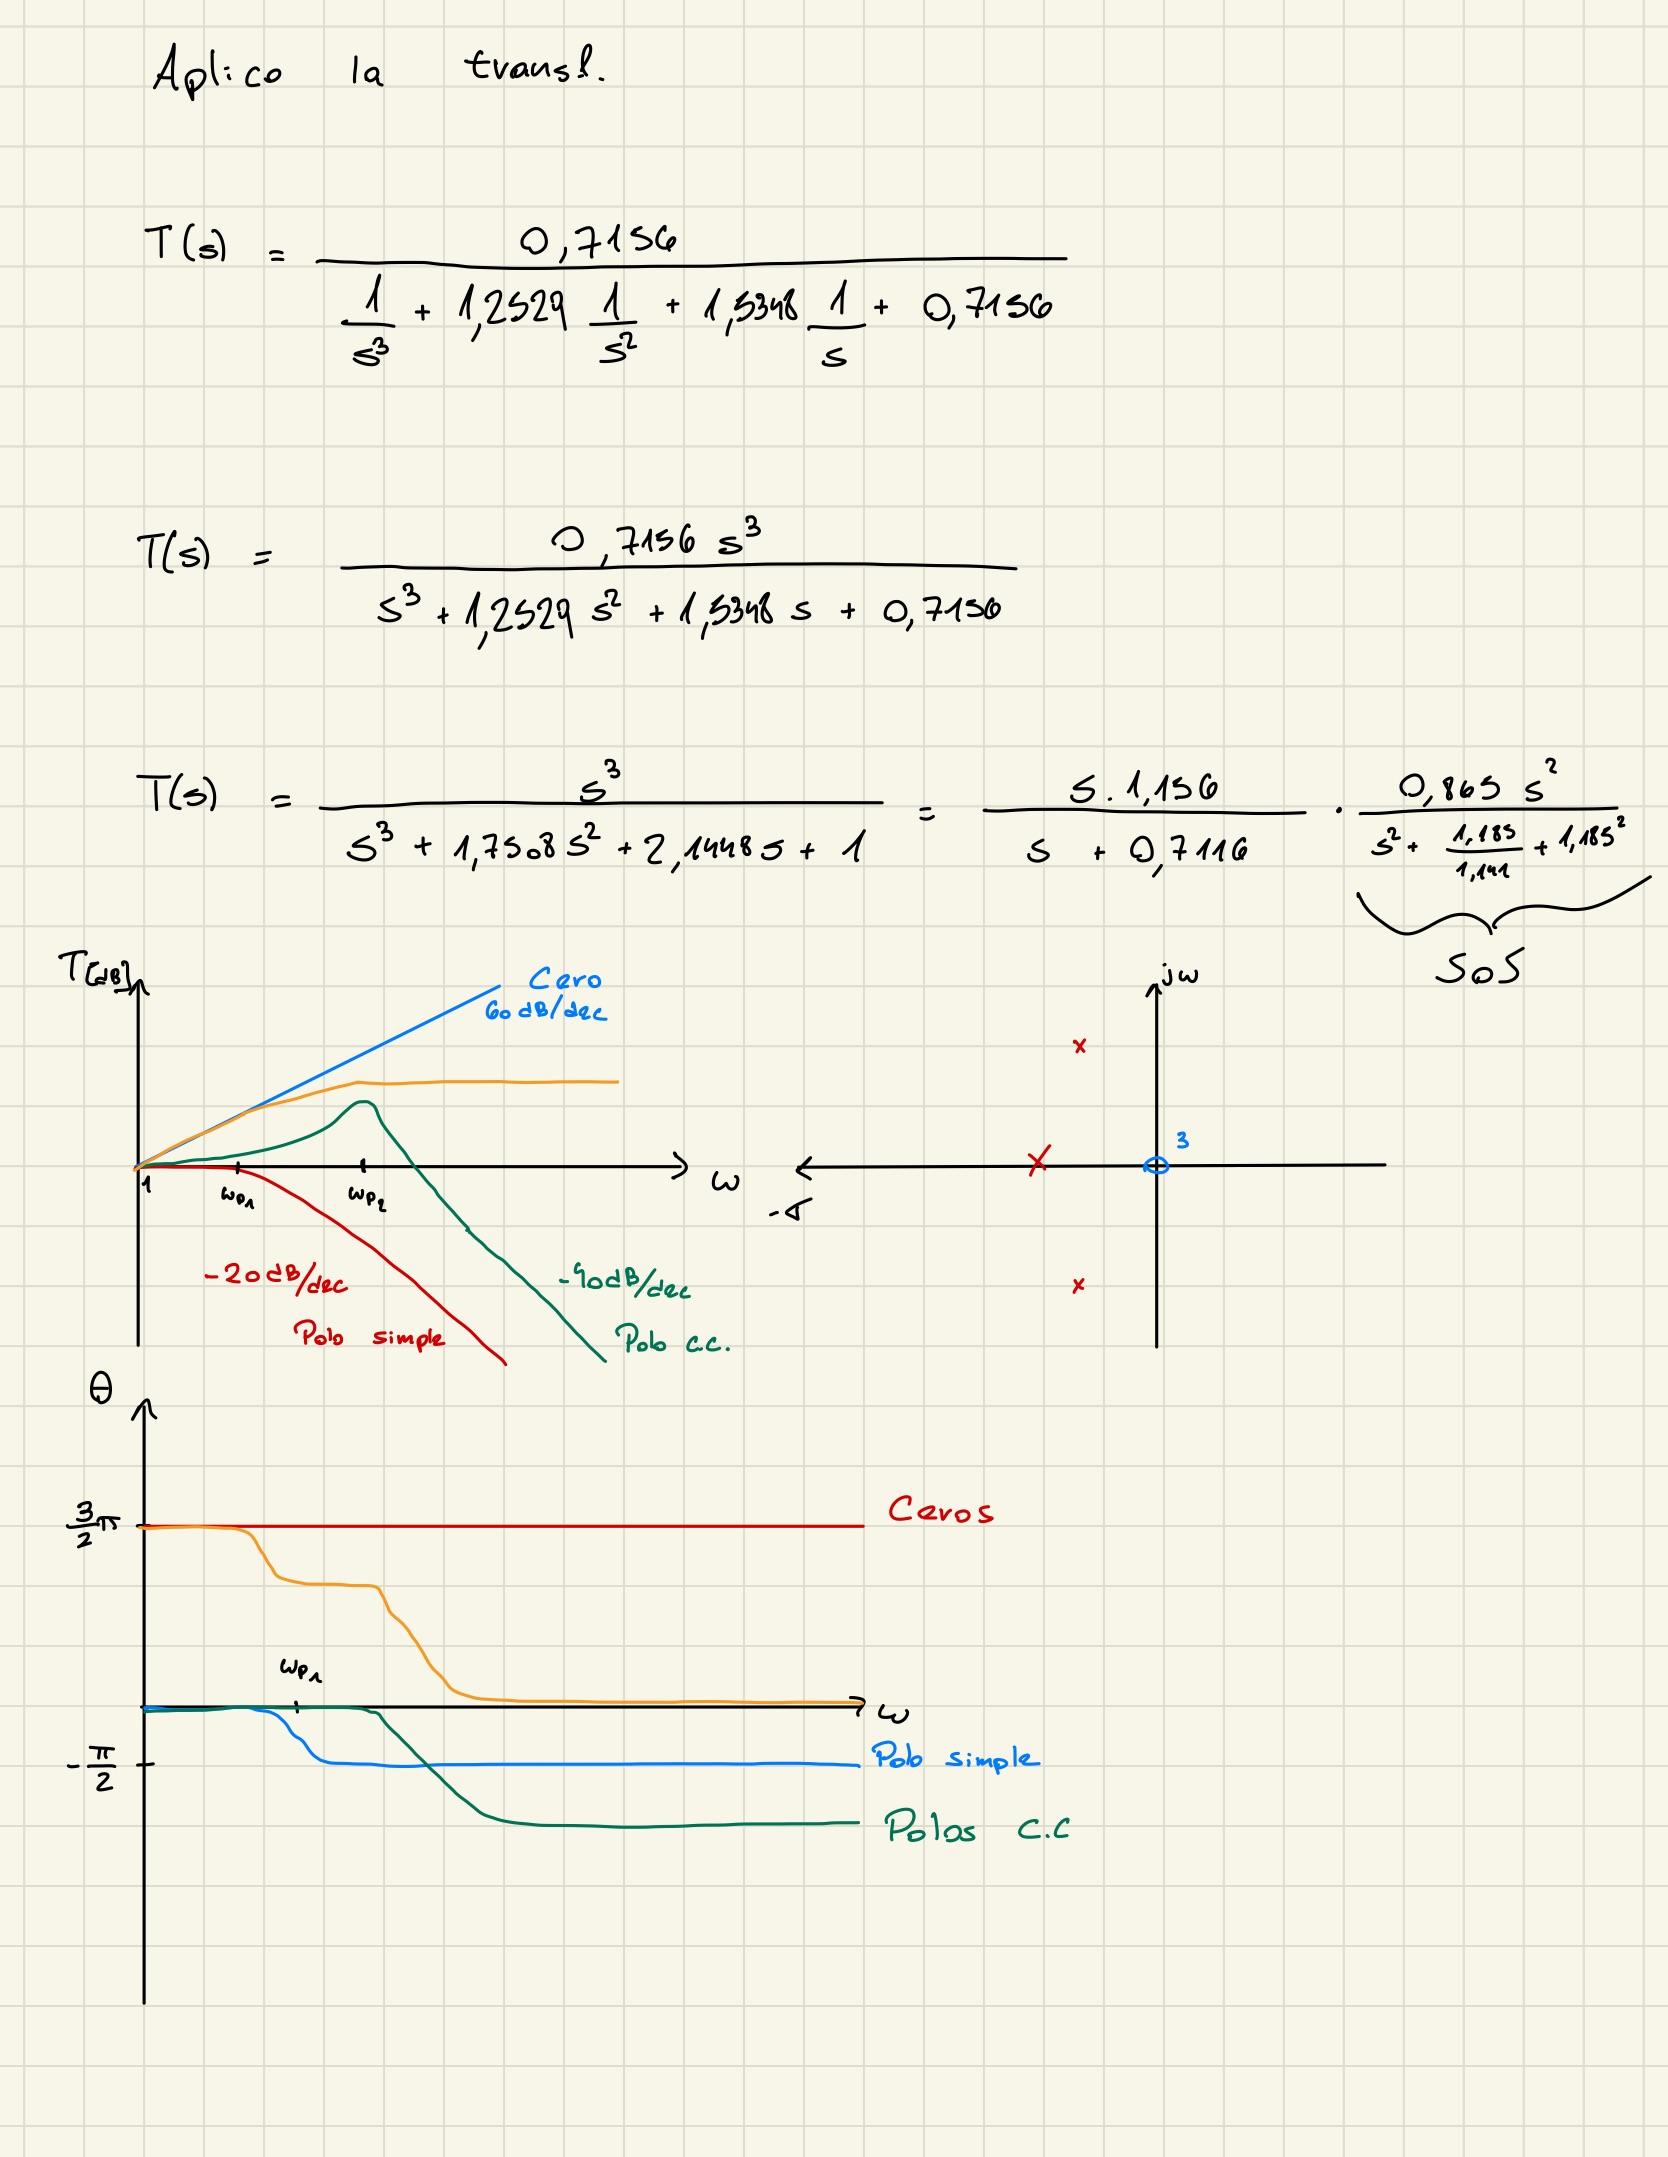

Nuevamente, se usa simulacion para comparar resultados. En este caso, con simpy se pueden obtener las SOS de la transferencia.  En el primer caso se ve la transferencia obtenida y en el segundo la misma normalizada a wo=1

In [ ]:
ripple = 0.5
orden = 3

z, p, k = sig.cheb1ap(orden, ripple)

eps =np.sqrt(10**(ripple/10)-1)
num, den = sig.zpk2tf(z,p,k)

sos_lp = tf2sos_analog(num, den)
pretty_print_SOS(sos_lp, mode = "omegayq")

den_from_poles = np.poly(z)

print(den_from_poles)

<IPython.core.display.Math object>

1.0


In [ ]:
num_hp = [1, 0, 0, 0]
den_hp = [1, 1.7508, 2.1448, 1]

sos_hp = tf2sos_analog(num_hp, den_hp)
pretty_print_SOS(sos_hp, mode = "omegayq")

<IPython.core.display.Math object>

A continuacion, se muestran los resultados numericos de Magnitud, fase y diagrama de polos y ceros.

(2, <Axes: xlabel='$\\sigma$', ylabel='j$\\omega$'>)

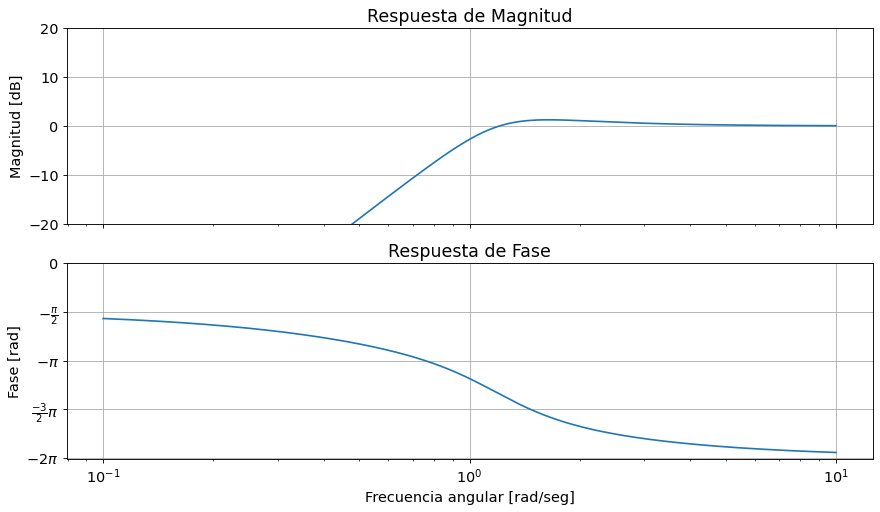

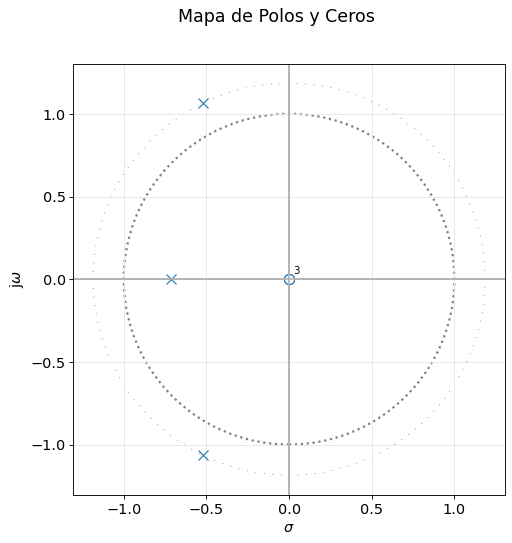

In [ ]:
num= np.array([1, 0, 0, 0])
den = np.array([1, 1.7508, 2.1448, 1])

TF = sig.TransferFunction(num, den)

_, axes_hdl = bodePlot(TF)

plt.sca(axes_hdl[0])
plt.ylim(-20, 20)
pzmap(TF)

Se puede notar que en la respuesta de fase, el graficador empieza por -90 en vez de 270, quitando ese detalle, la respuesta es identica a la obtenida analiticamente.

Ahora, se implementa el sistema utilizando circuitos pasivos.

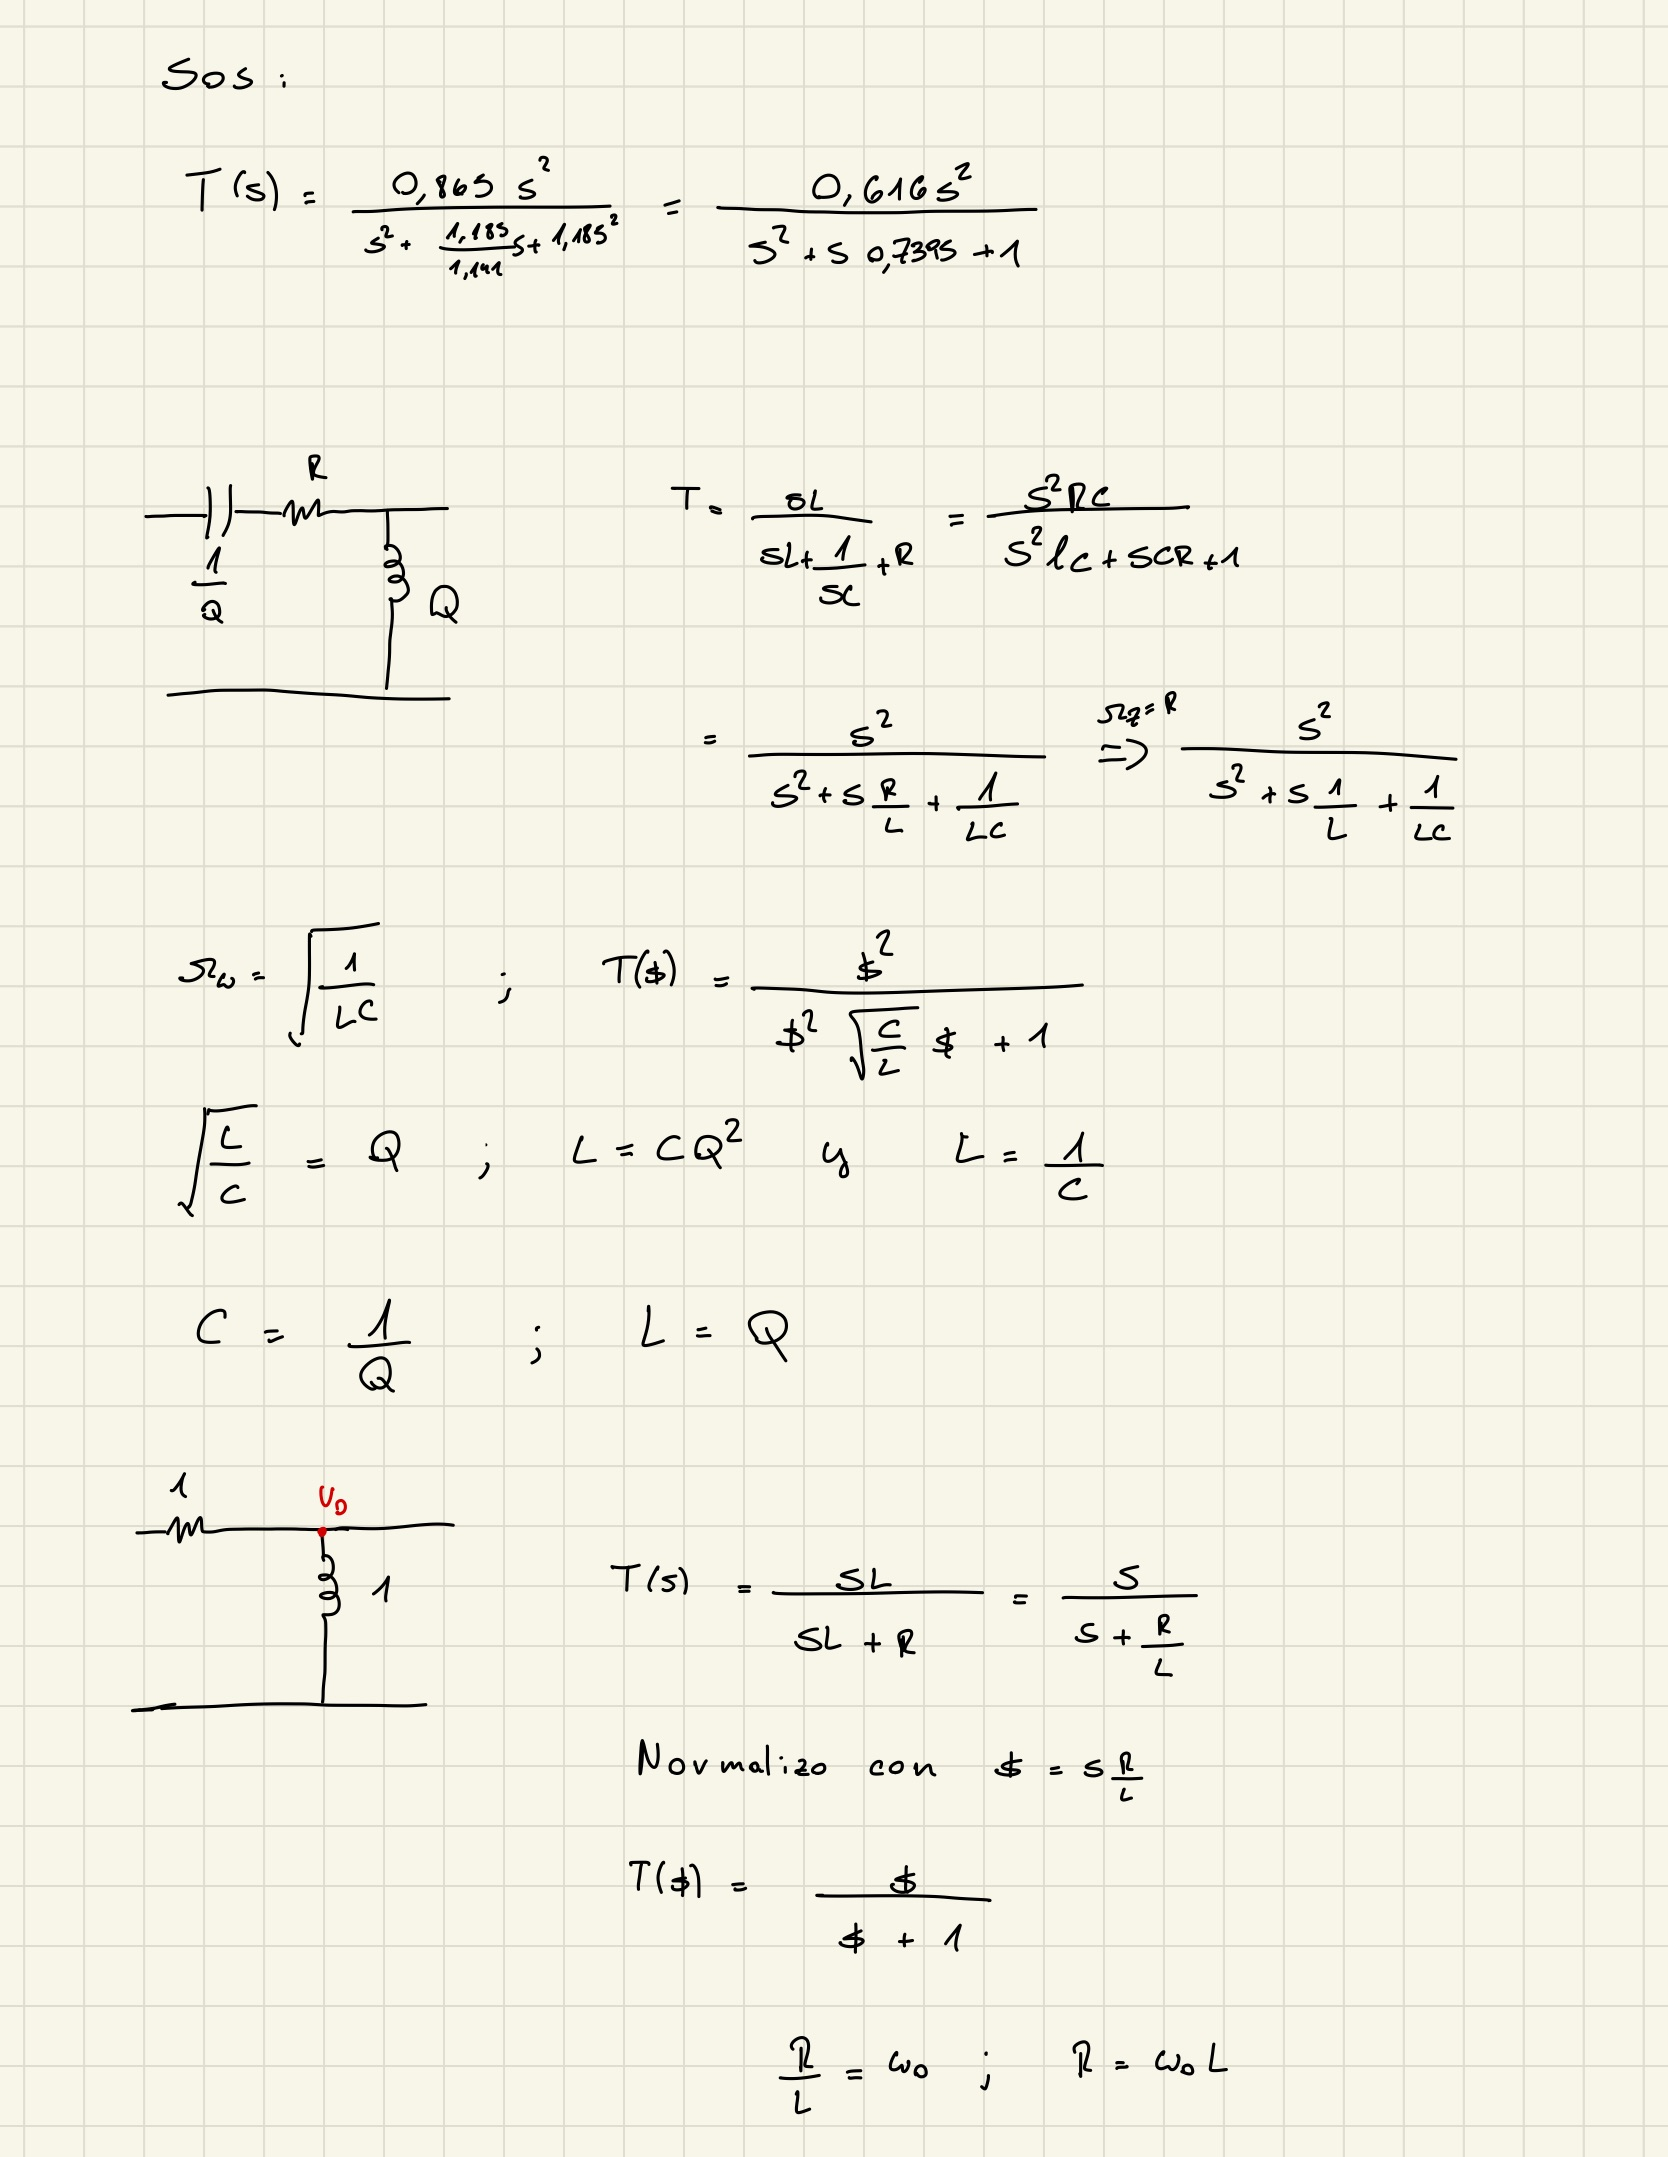

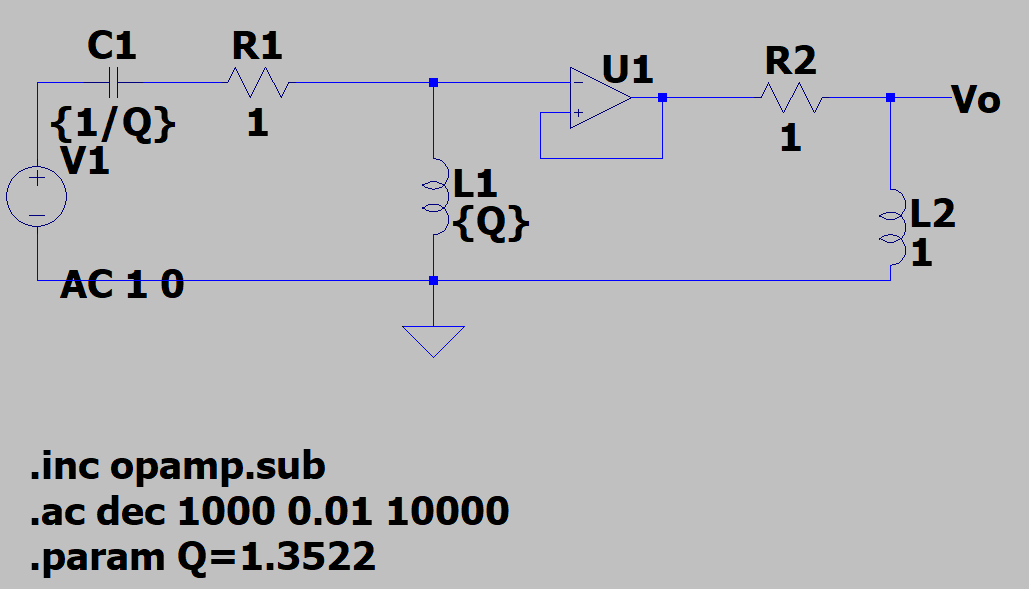

Respuesta de modulo y fase:

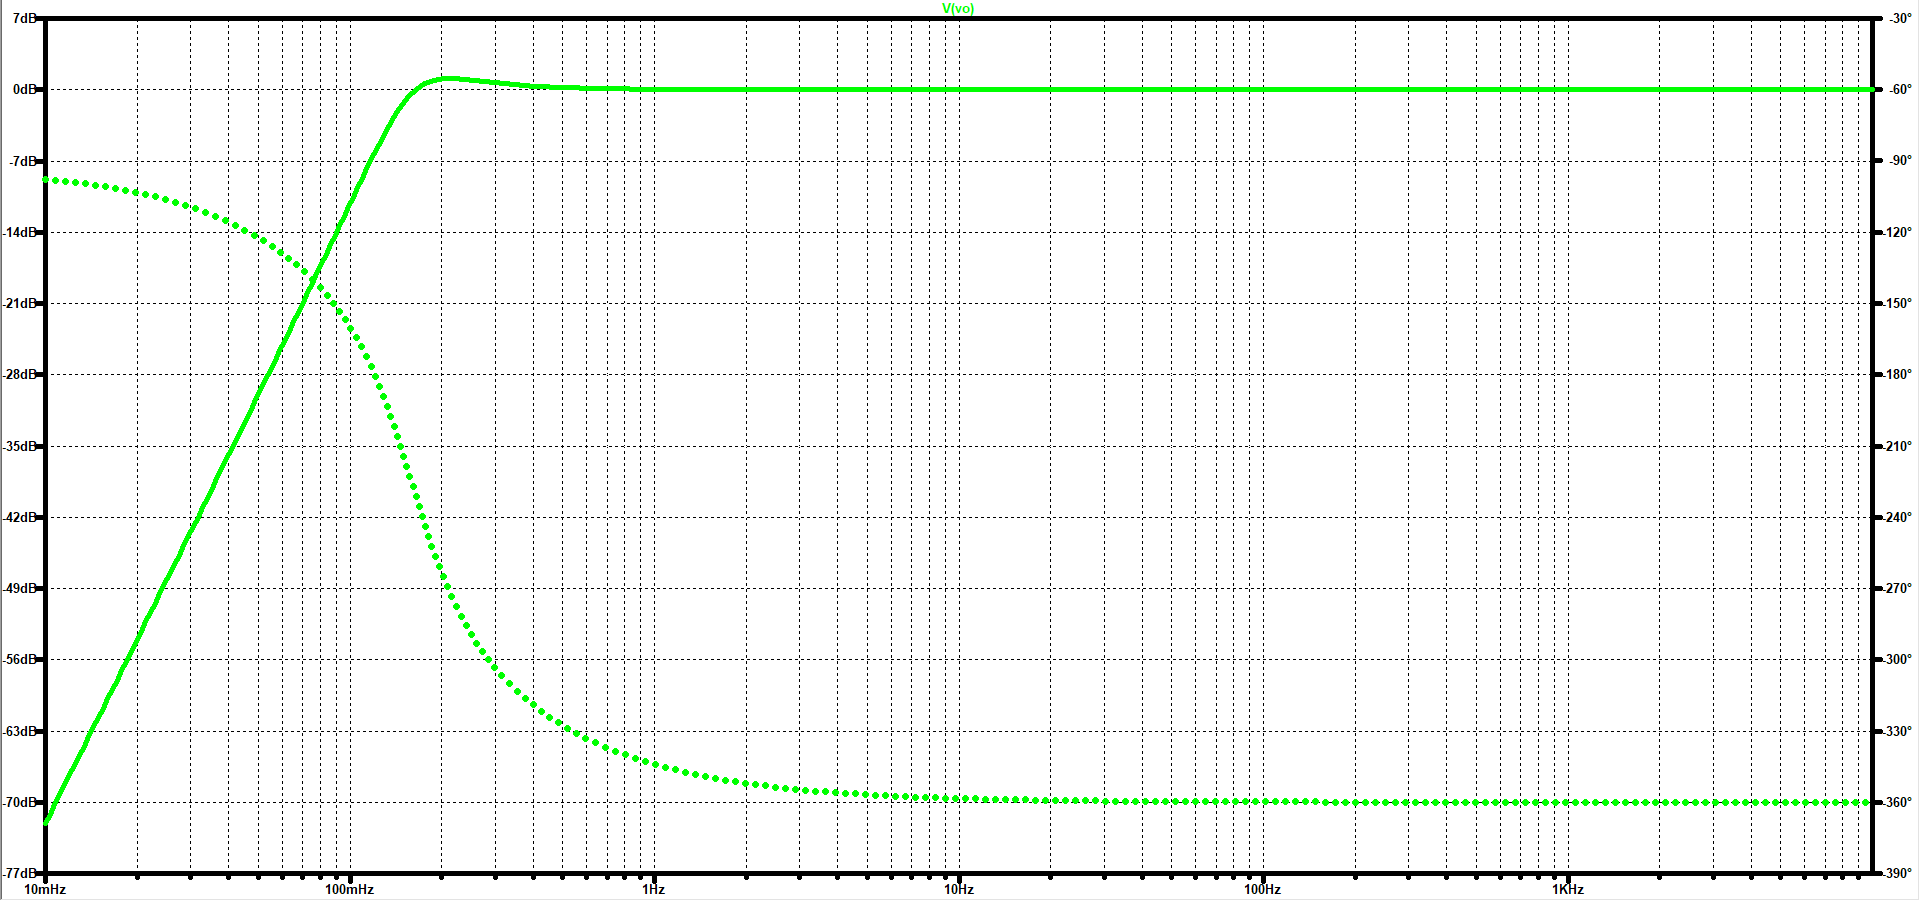

Se puede notar que es comparaable con los resultados cualitativos y numericos.

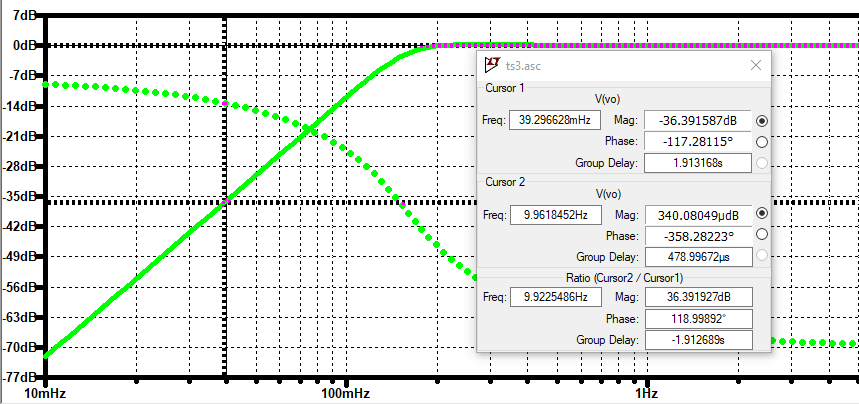

El objetivo de alfa_min era de -30dB para 0.25 la Wo. Si Wo=159mHz, tiene que haber al menos -30dB en 0,3975mHz, lo cual se cumple.

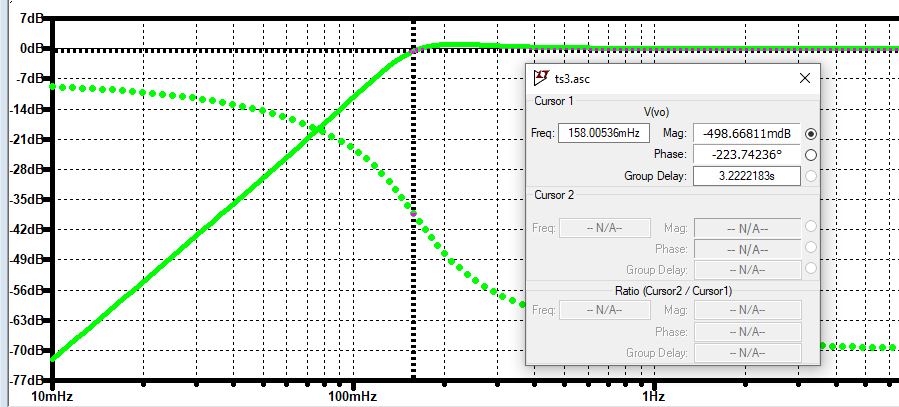

Tambien se puede notar el ripple de 0,5 en Wo.

Ahora reemplazo los inductores por GICs.

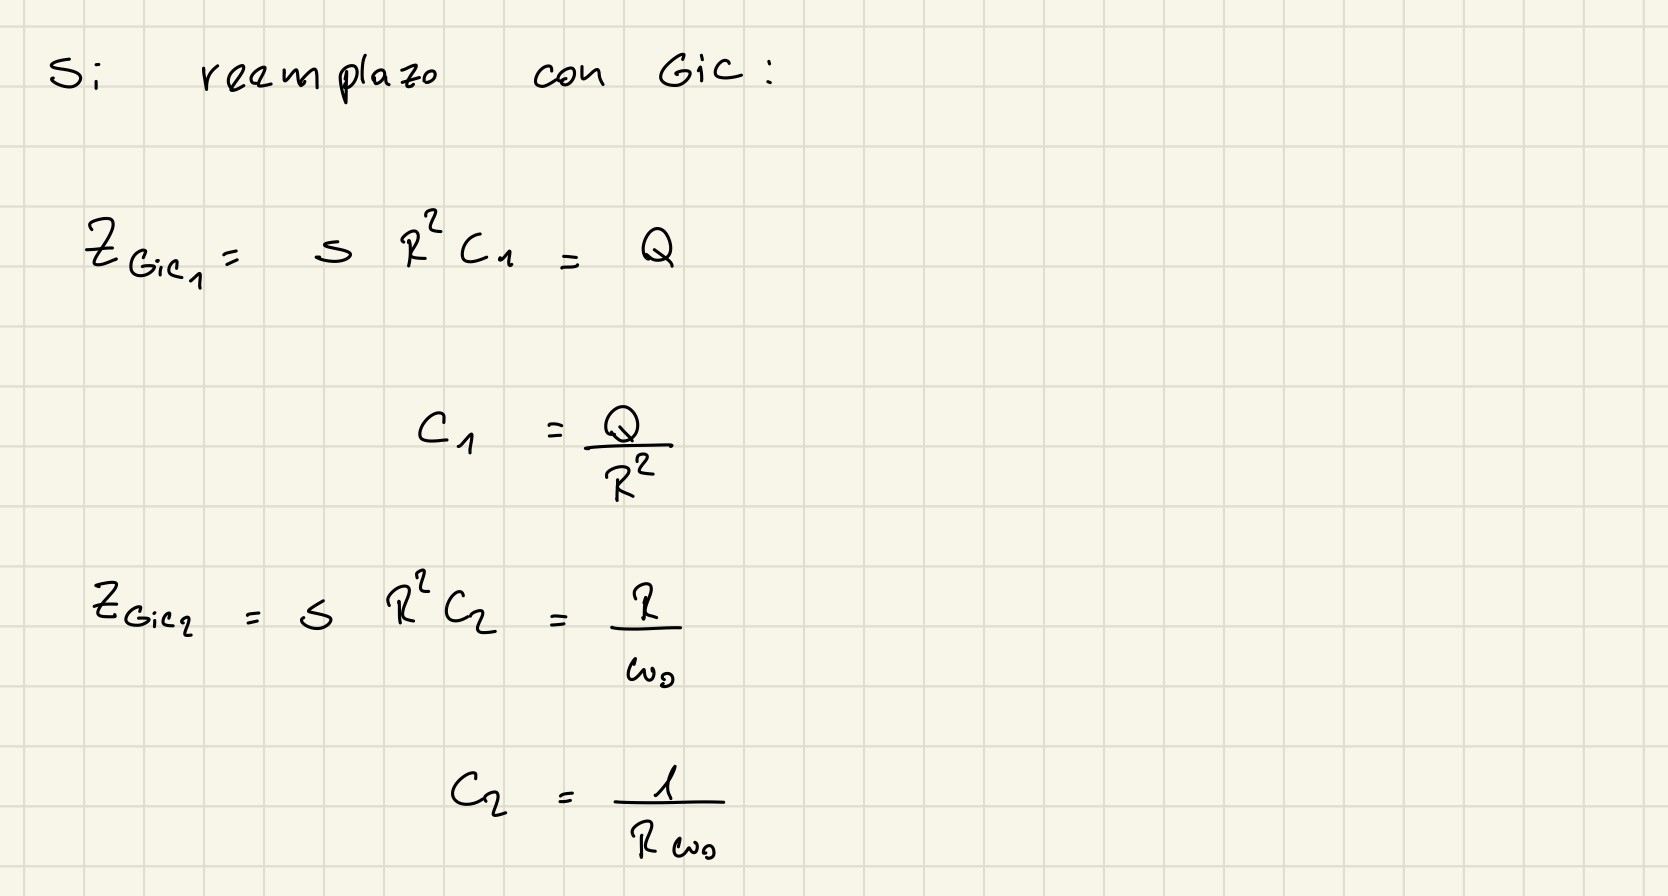

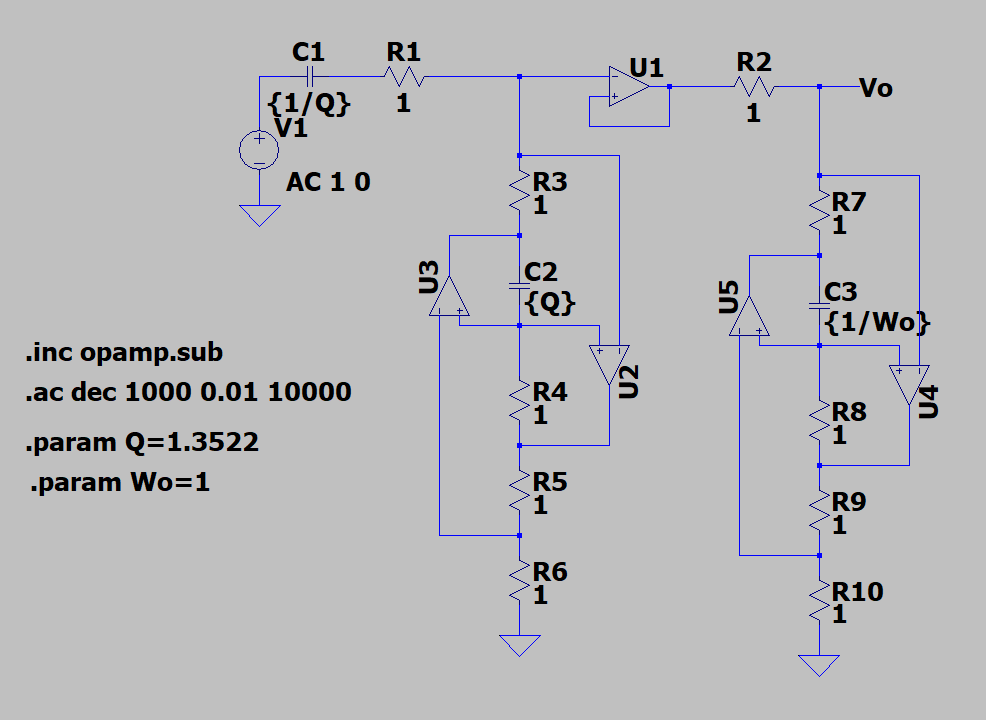

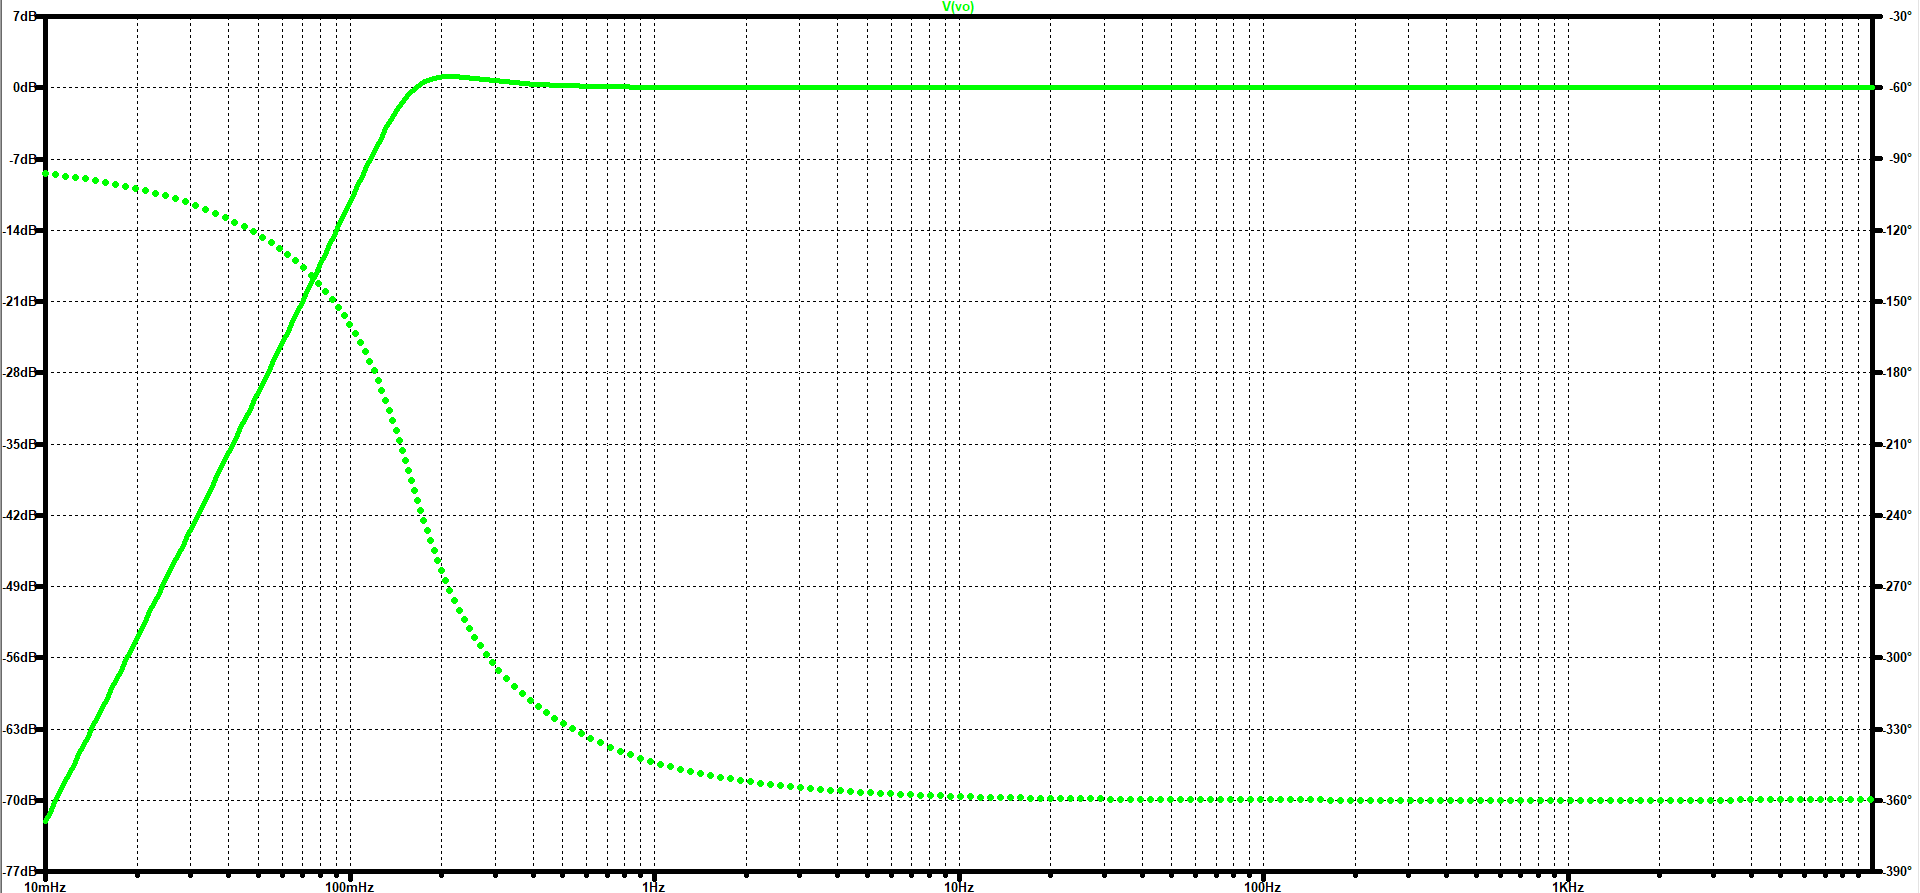

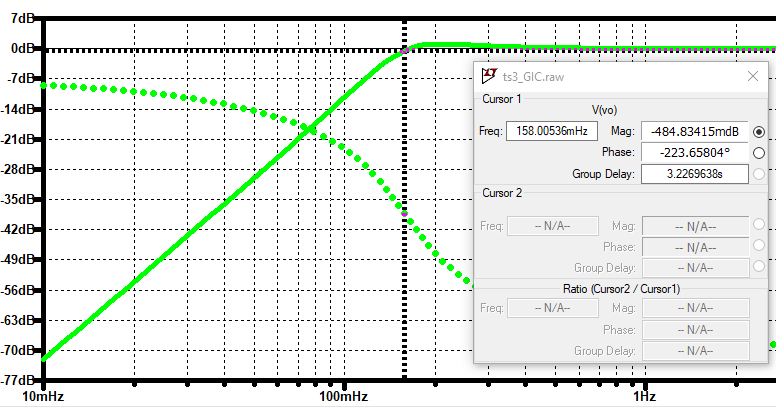

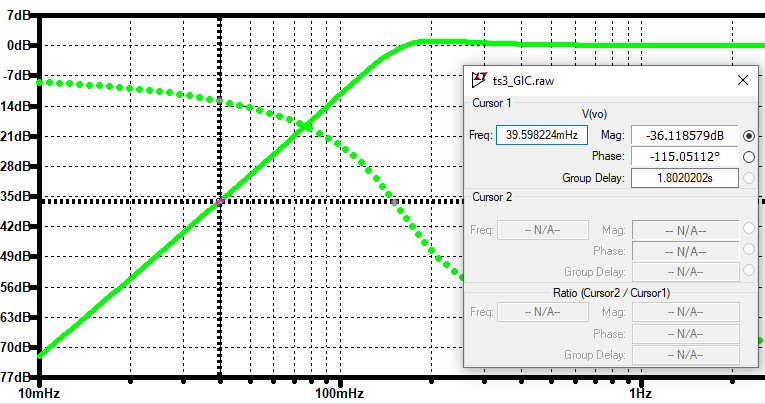

Se puede observar que los resultados son los mismos.

Ahora, se reemplaza la SOS con un MFB pasa-altos.

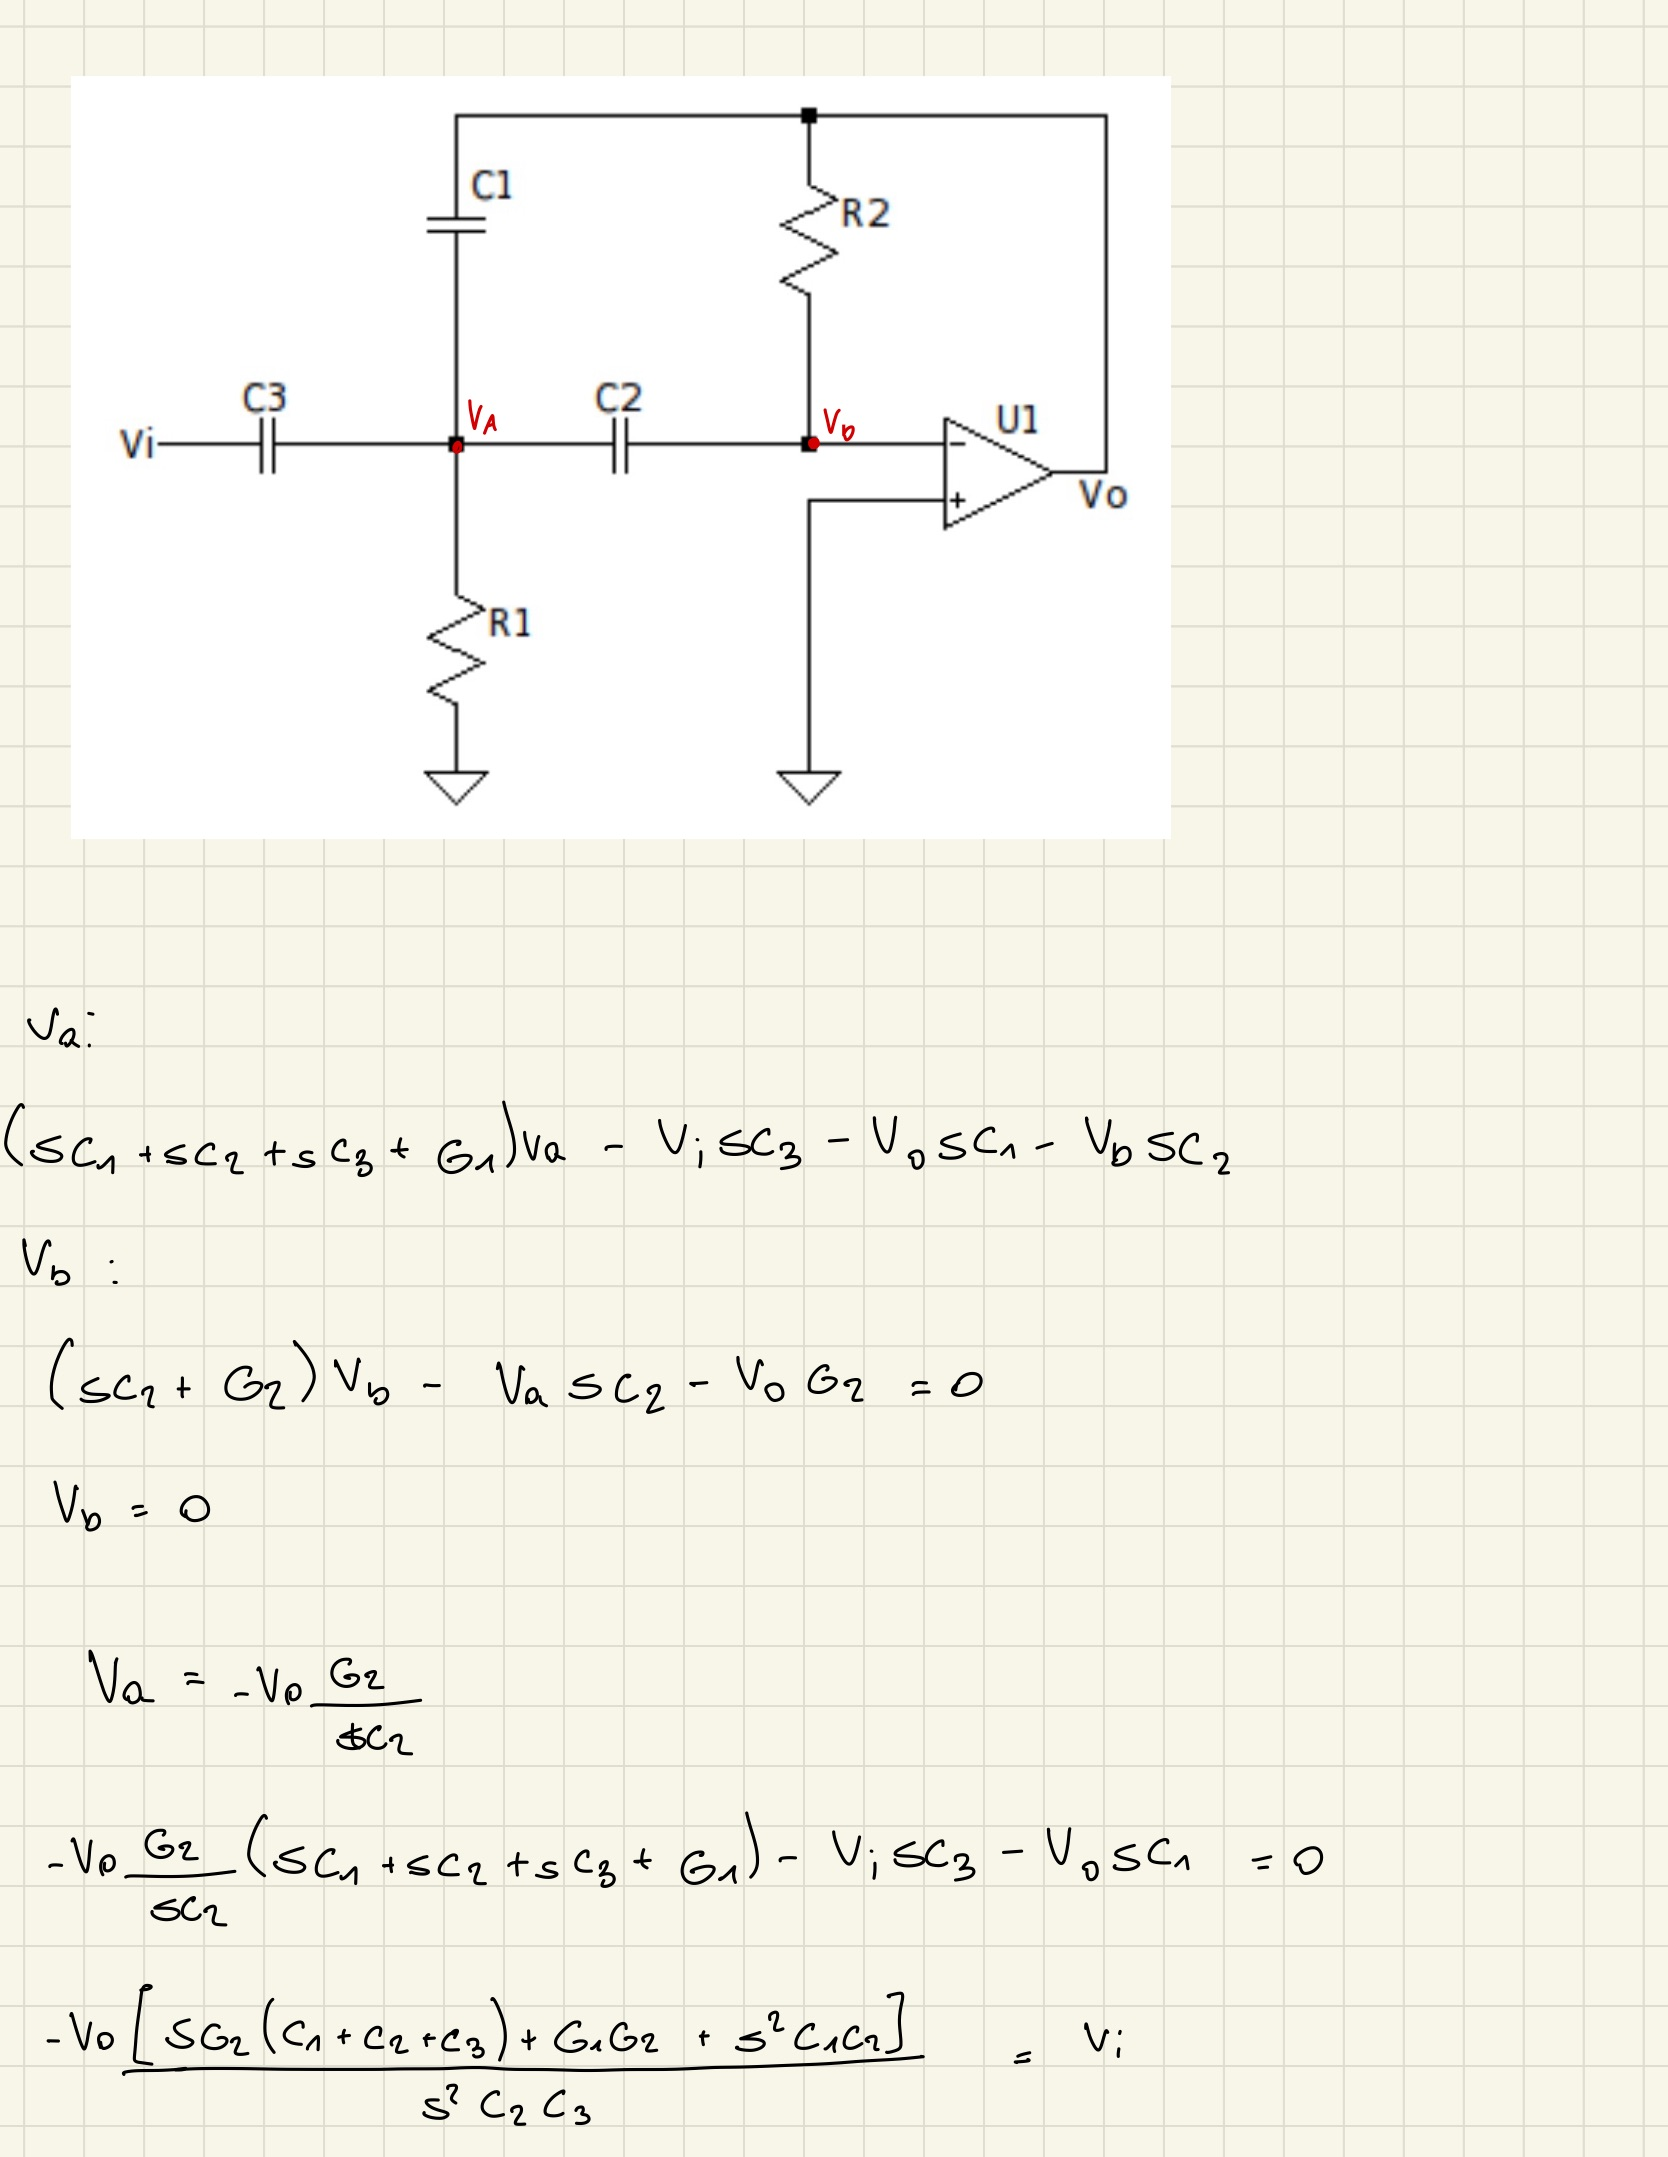

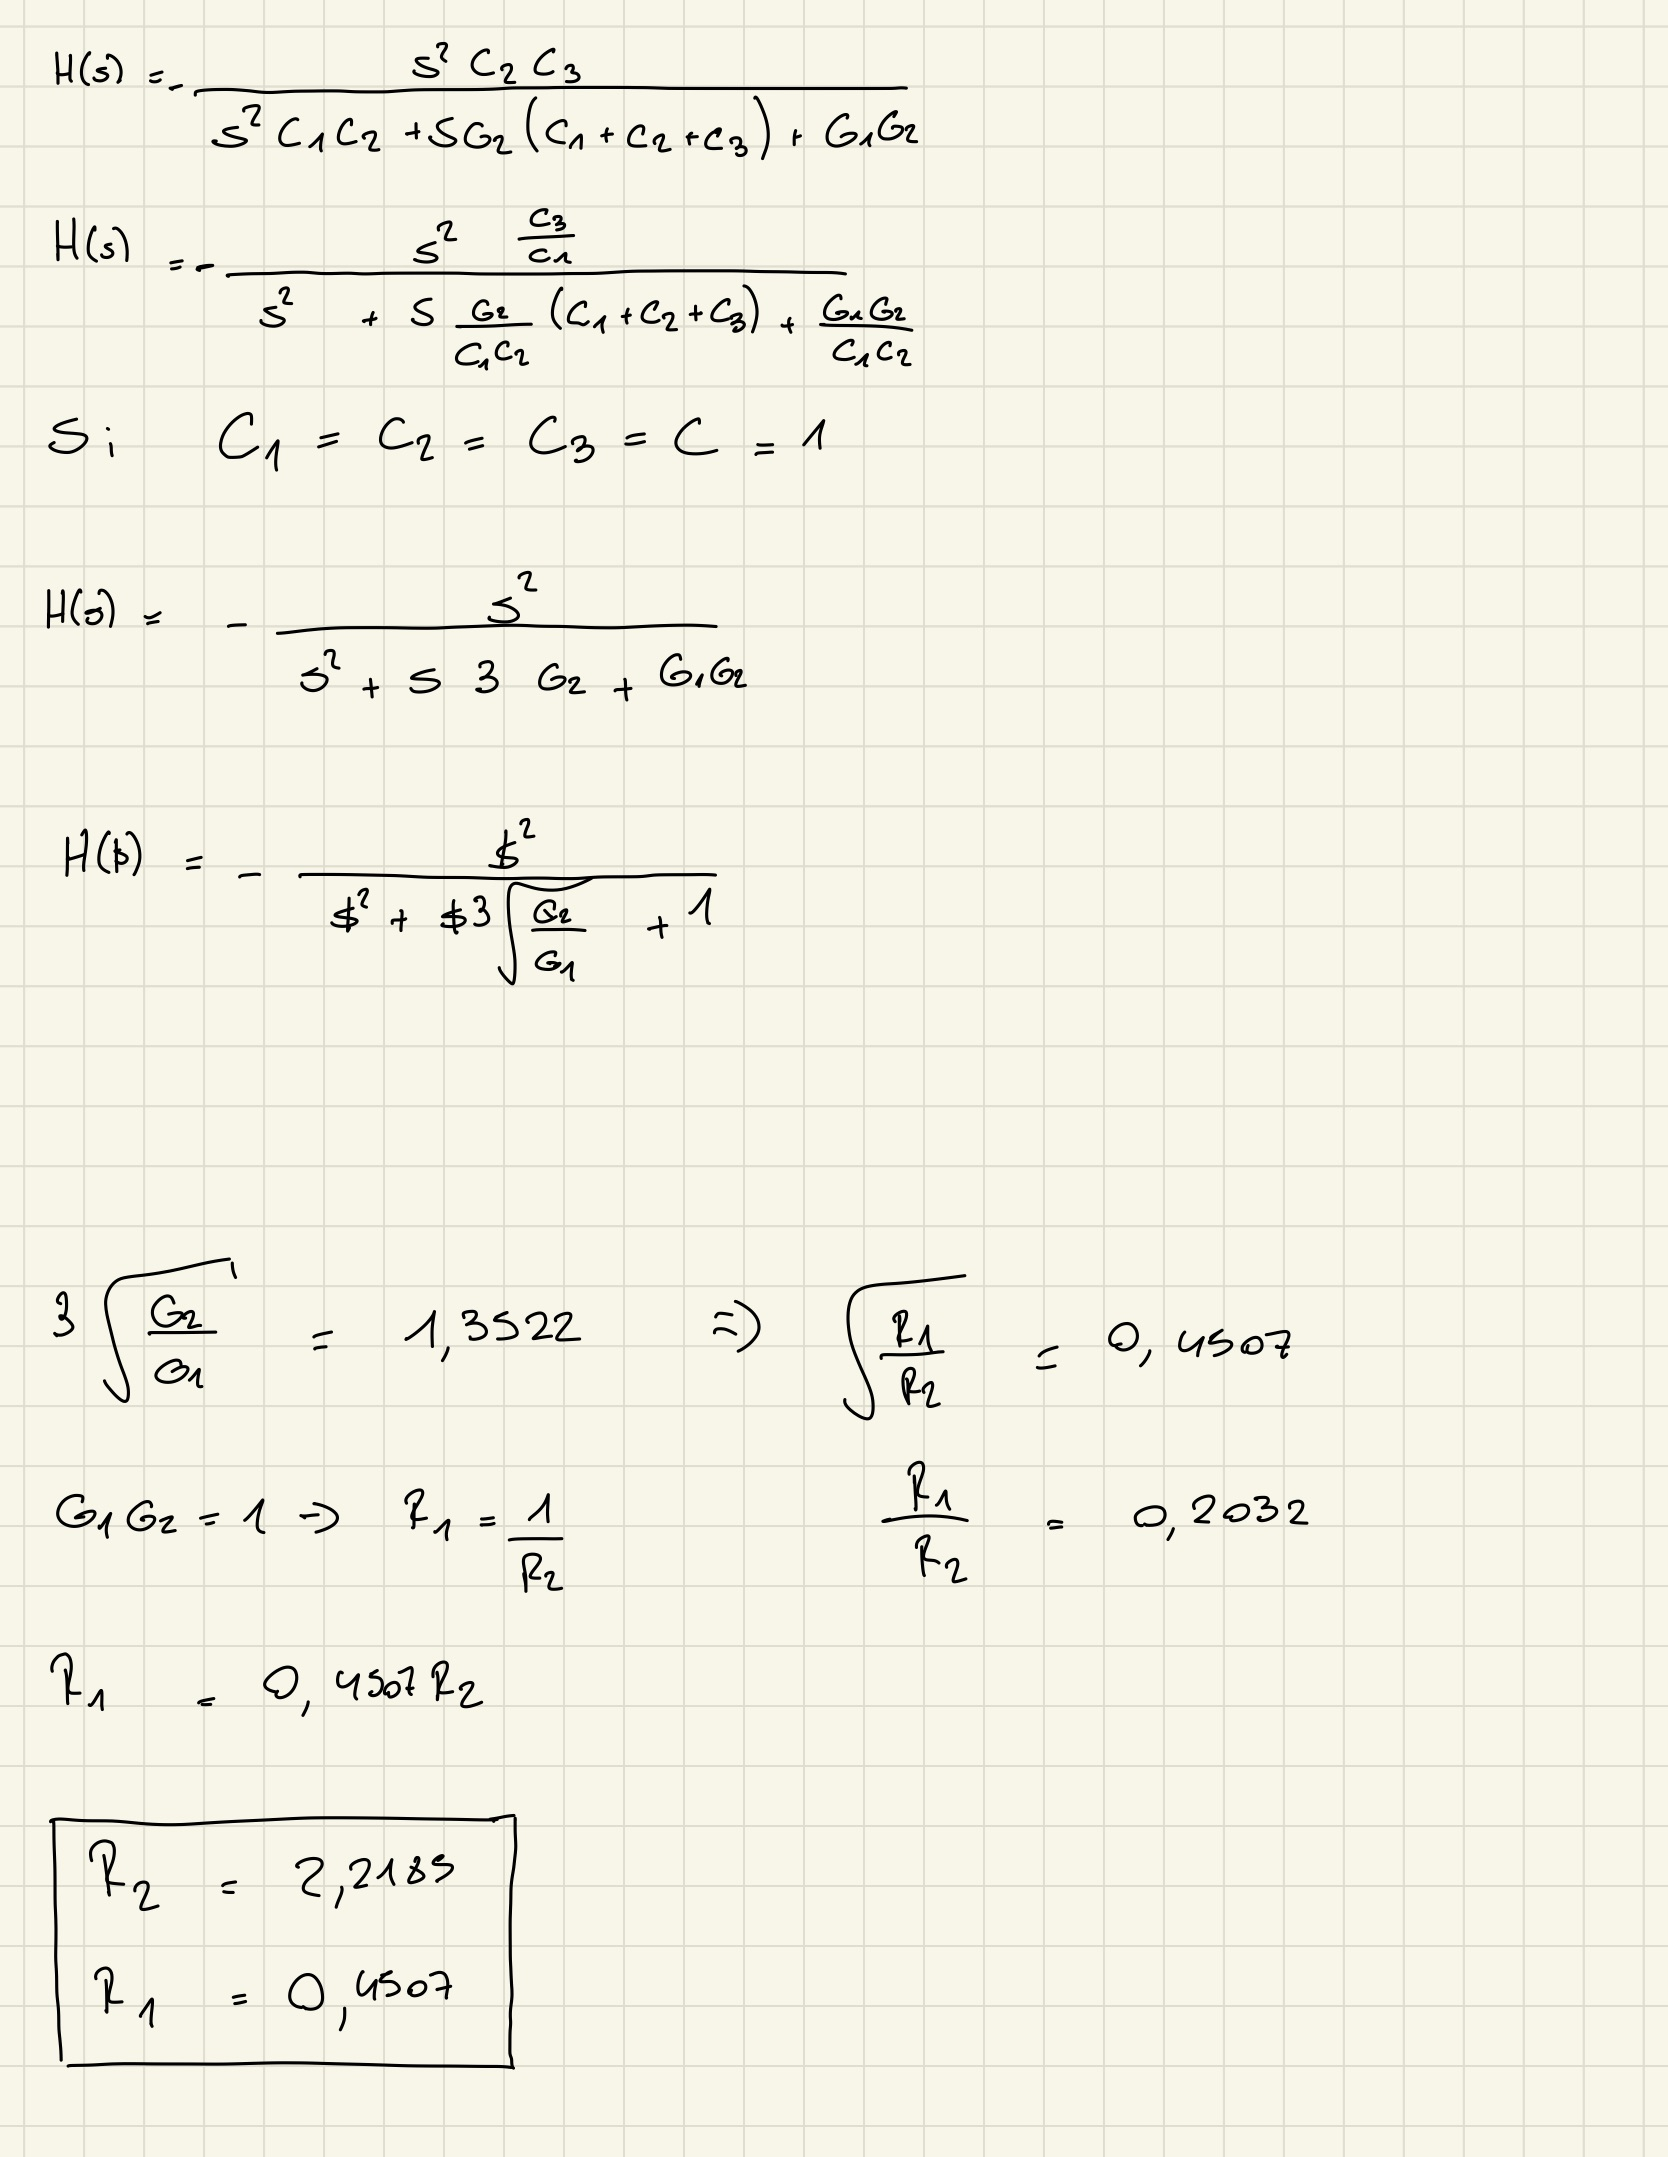

![Captura de pantalla (417).png](<attachment:Captura de pantalla (417).png>)
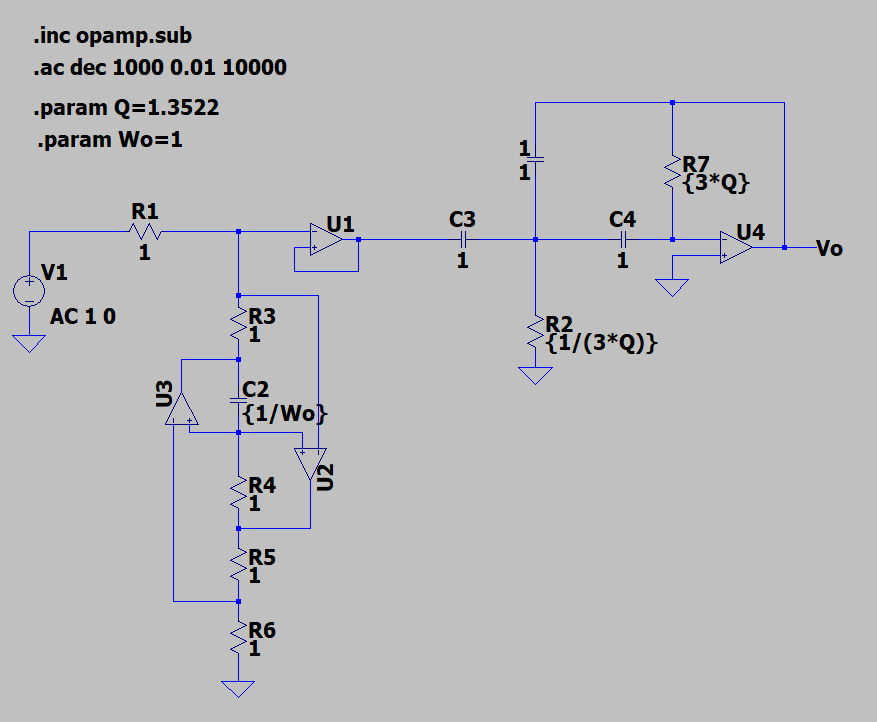

![Captura de pantalla (418).png](<attachment:Captura de pantalla (418).png>)
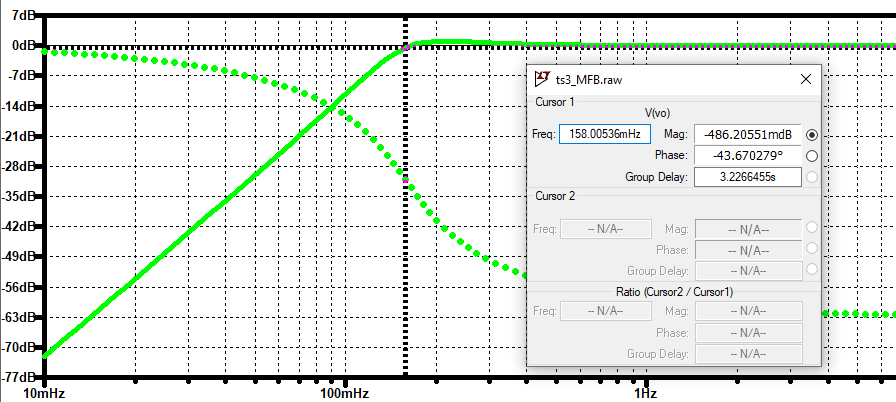

![Captura de pantalla (419).png](<attachment:Captura de pantalla (419).png>)
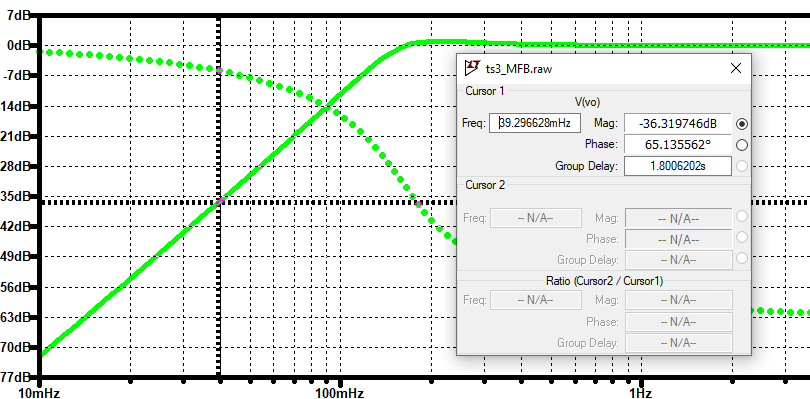

Se pueden ver los mismos resultados obtenidos con los dos circuitos anteriores.

###Sensibilidad de los parametros

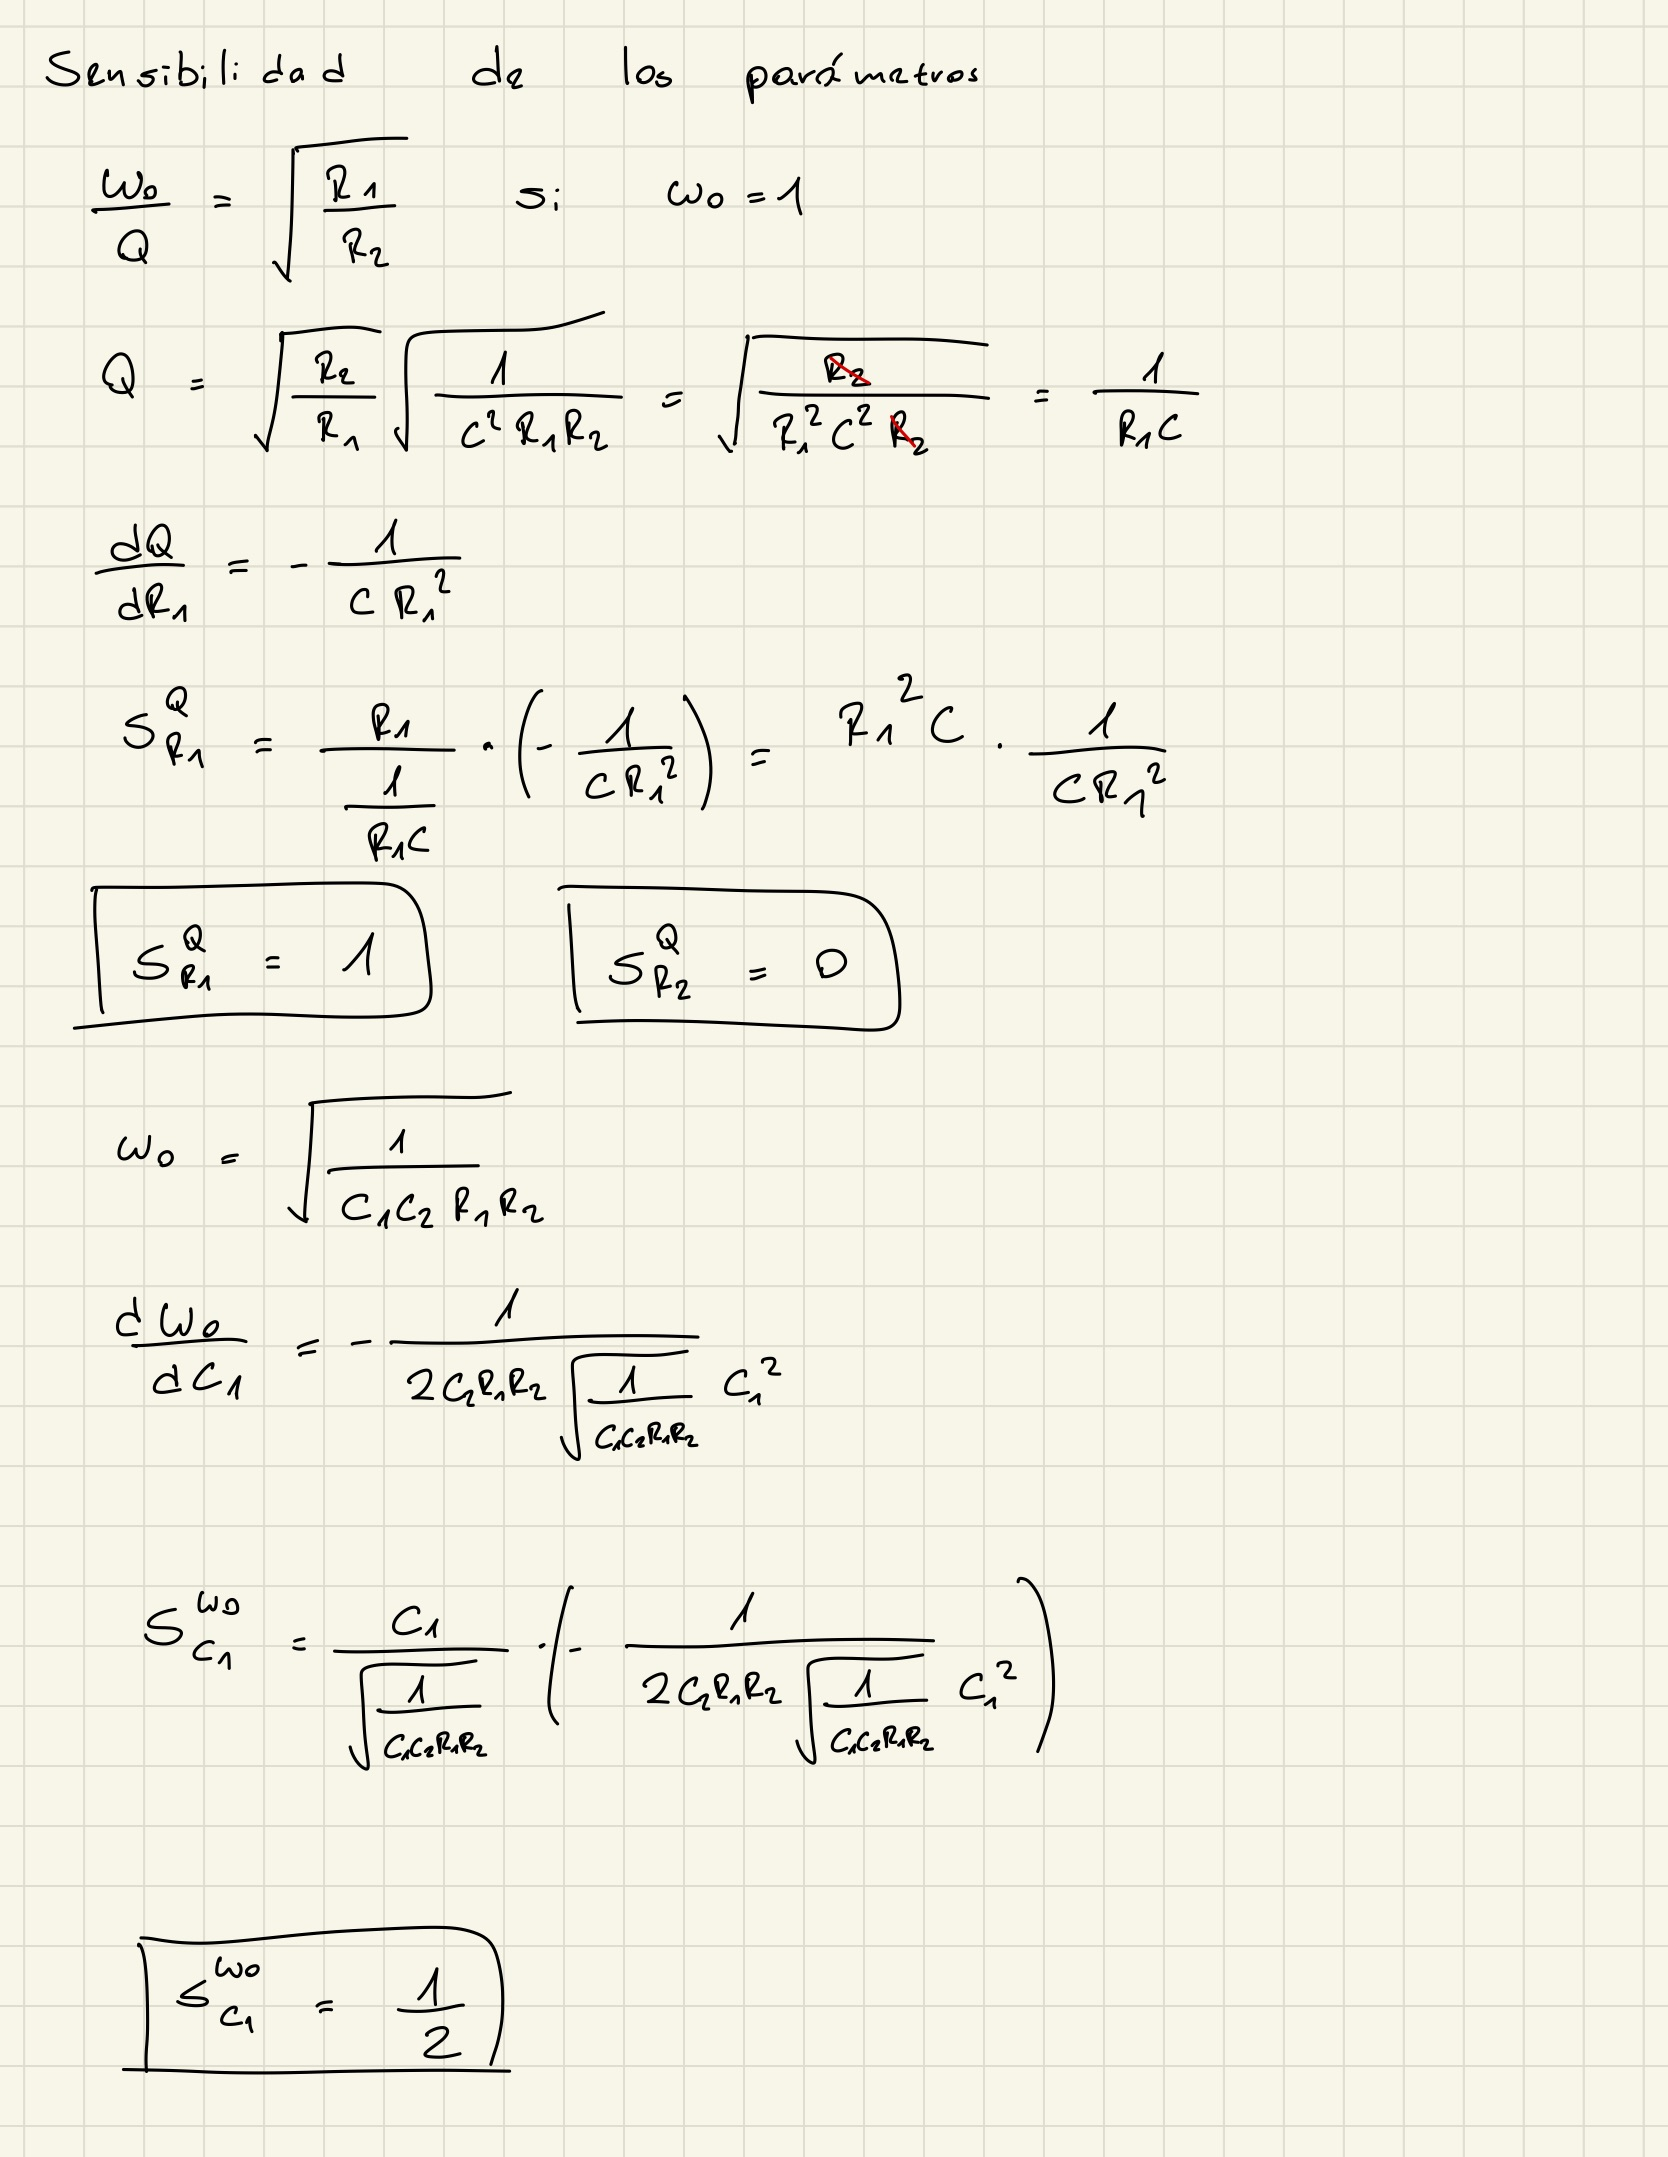